In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
#import time
import matplotlib.pyplot as plt

import warnings

import utils

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

In [2]:
df_portofolio, df_quotes, _, _ = utils.load_data()
df_quotes = df_quotes.bfill()
code2name_dict = df_portofolio['Nome'].to_dict()

In [3]:
def get_quote_date(days_ago: int):
    return df_quotes.index[df_quotes.index <= (df_quotes.index[0]-pd.Timedelta(days=days_ago))].max()

def oscilator(ts, period=21, smooth_k=3):
    # Calculate the highest high and lowest low over the specified period
    data = ts.sort_index()[-period-smooth_k:]
    highest_high = data.rolling(window=period).max()
    lowest_low = data.rolling(window=period).min()
    
    # Calculate %K
    percent_k = ((data - lowest_low) / (highest_high - lowest_low)) * 100
    
    # Smooth %K using a moving average
    smooth_k_line = percent_k.rolling(window=smooth_k).mean()
    return smooth_k_line.iloc[-2:]

div_f = 365 / 53
def get_kpis(days_ago: int = 365 //div_f, base_return: float=0.03):
    days_ago_std = 365 // 2
    start_date = get_quote_date(days_ago=days_ago)
    start_date_std = get_quote_date(days_ago=days_ago_std)
    df_features = pd.DataFrame(index=df_quotes.columns)
    #df_features['Name'] = df_features.apply(lambda x: code2name_dict.get(x.name,x.name),axis=1)
    df_features['Growth'] = df_quotes.apply(lambda x: (x.iloc[0]/x.loc[start_date])**(div_f)-1)
    df_features['STD'] = df_quotes.loc[:start_date_std].apply(lambda x: x/x.shift(-1), axis=0).std(axis=0)
    df_features['Racio'] = (df_features['Growth']-base_return)/df_features['STD']
    ds = df_quotes.loc[:start_date].apply(lambda x: x/x.shift(-1)-1, axis=0).clip(upper=0)**2
    df_features['D_Volat'] = np.sqrt(ds.mean())
    df_features['Racio2'] = (df_features['Growth']-base_return)*2/(df_features['STD'] + df_features['D_Volat']*2)
    ts_min, ts_max, ts_last = df_quotes.min(), df_quotes.max(), df_quotes.iloc[0,:]
    df_features['PricePosition'] = (ts_last-ts_min)/(ts_max-ts_min)
    osc_df = df_quotes.apply(lambda x: oscilator(x), axis=0)
    df_features['Oversold Exit'] = osc_df.apply(lambda x: (x.iloc[1]>20) & (x.iloc[0]<20))
    df_features['Overbought Entry'] = osc_df.apply(lambda x: (x.iloc[1]>80) & (x.iloc[0]<80))
    return df_features[df_features['STD']>0].sort_values(by='Racio',ascending=False)

df_features = get_kpis()
last_quotes = df_quotes.iloc[0]
df_features['Amount EUR'] = last_quotes * df_portofolio['Quantidade']

In [4]:
def change_trend(ts: pd.Series, long_window: int=30, short_window:int=10, kpi_window:int=130, lag:int=1):
    ts = ts.sort_index()
    short_ma = ts.ewm(span=short_window, adjust=False).mean()
    short_ma.name = 'short_ma'
    long_ma = ts.ewm(span=long_window, adjust=False).mean()
    long_ma.name ='long_ma'
    if short_ma.iloc[-1-lag] < long_ma.iloc[-1-lag] and short_ma.iloc[-1] > long_ma.iloc[-1]:
        # Short-term MA crosses above long-term MA: Upward trend
        status = "Up"
    elif short_ma.iloc[-1-lag] > long_ma.iloc[-1-lag] and short_ma.iloc[-1] < long_ma.iloc[-1]:
        # Short-term MA crosses below long-term MA: Downward trend
        status = "Down"
    else:
        # No recent trend change
       status = "NaN"
    sma_growth = short_ma.iloc[-1] / short_ma.iloc[-1-short_window]
    ts_min, ts_max = ts.iloc[-kpi_window:].min(), ts.iloc[-kpi_window:].max()
    price_position = (ts.iloc[-1]-ts_min)/(ts_max-ts_min)
    return status, short_ma, long_ma, sma_growth, price_position

def volatility(returns: pd.Series):
    return np.sqrt((returns**2).mean())

def print_fund_change(symb: str):
    _, sma, lma,_,_ = change_trend(df_quotes[symb])
    df_tmp = pd.concat([df_quotes[symb],sma,lma],axis=1)
    title = code2name_dict.get(symb,'')
    df_tmp.iloc[:130].plot(title=title,figsize=(12,4))
    plt.show()
    #returns = df_quotes[symb].pct_change().dropna()
    #avg_returns = returns.mean()
    #print(f"Downside Volatiliy:{volatility(returns.clip(upper=avg_returns))}. Upside Volatiliy:{volatility(returns.clip(lower=avg_returns))}.")

def plot_stochastic_oscillator(symb: str, period=14, smooth_k=3, smooth_d=3):
    """
    Calculate and plot the Stochastic Oscillator for an asset.
    
    Parameters:
        symb (str): The symbol to use.
        period (int): The lookback period for calculating the Stochastic Oscillator. Default is 14.
        smooth_k (int): The smoothing period for %K. Default is 3.
        smooth_d (int): The smoothing period for %D (signal line). Default is 3.
    """
    # Ensure the symbol is valid
    if symb not in df_quotes.columns:
        raise ValueError(f"The symbol '{symb}' does not exist in the data.")
    
    data = df_quotes[symb].sort_index()
    
    # Calculate the highest high and lowest low over the specified period
    highest_high = data.rolling(window=period).max()
    lowest_low = data.rolling(window=period).min()
    
    # Calculate %K
    percent_k = ((data - lowest_low) / (highest_high - lowest_low)) * 100
    
    # Smooth %K using a moving average
    smooth_k_line = percent_k.rolling(window=smooth_k).mean()
    
    # Calculate %D (signal line) as a moving average of %K
    percent_d = smooth_k_line.rolling(window=smooth_d).mean()
    
    # Plot the Stochastic Oscillator
    plt.figure(figsize=(12, 2))
    plt.plot(smooth_k_line.iloc[-130:], label=f"%K (Fast Line, {smooth_k}-period)", color='lightblue')
    #plt.plot(percent_d, label=f"%D (Signal Line, {smooth_d}-period)", color='orange')
    plt.axhline(80, color='red', linestyle='--', label='Overbought (80)')
    plt.axhline(20, color='green', linestyle='--', label='Oversold (20)')
    #plt.title(f"{code2name_dict.get(symb,'')} Stochastic Oscillator")
    #plt.xlabel("Date")
    #plt.ylabel("Oscillator Value")
    #plt.legend()
    #plt.grid()
    plt.show()

def buy_opps_change_trend(lag:int=1,growth_treshold:int=1.0005, relative_price_treshold:int=1.5, graph=True):
    print("####################  BUY OPPS  #####################")
    df_change_opp = pd.DataFrame(
        [(symb,g,pp) for x,_,_,g,pp,symb in [change_trend(ts=df_quotes[symb],lag=lag)+(symb,) for symb in df_quotes.columns] if x == 'Up'],
        columns=['symb','growth','relative_price']
        ).sort_values(by='relative_price')
    df_change_opp = df_change_opp[(df_change_opp['growth']>growth_treshold) & (df_change_opp['relative_price']<relative_price_treshold)]
    if graph:
        for symb in df_change_opp['symb']:
            print_fund_change(symb)
    return df_change_opp['symb']

def sell_opps(lag:int=1):
    print("####################  SELL OPPS  #####################")
    df_change_opp = pd.DataFrame(
        [(symb,g,pp) for x,_,_,g,pp,symb in [change_trend(df_quotes[symb], lag=lag)+(symb,) for symb in df_portofolio.index] if x == 'Down'],
        columns=['symb','growth','relative_price']
        ).sort_values(by='relative_price')
    for symb in df_change_opp['symb']:
        print_fund_change(symb)
    return df_change_opp['symb']

def portofolio_trend(fund_list=df_portofolio.index):
    print("####################  PORTOFOLIO TRENDS  #####################")
    for symb in fund_list:
        print_fund_change(symb)


### Evaluate Portofolio

In [5]:
df_plot = df_features.loc[df_portofolio.index].sort_values(by='Racio2',ascending=False)
df_plot['Name'] = df_plot.apply(lambda x: code2name_dict.get(x.name,''),axis=1)
df_plot.sort_values(by=['Racio2'],ascending=False).to_csv('portfolio_tmp_2.csv')
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR,Name
Code,,,,,,,,,,
LU0300834669,0.935369,0.012560,72.084248,0.005161,79.135695,1.000000,False,False,31784.970173,Alken Fund Small Cap Europe Class R
LU1965927921,0.034115,0.000114,35.992632,0.000000,71.985264,1.000000,False,False,109070.000000,DWS Invest ESG Floating Rate
LU0524465977,0.600643,0.012689,44.971993,0.004931,50.609721,0.997548,False,False,30962.296114,Alken European Opport A
META,0.668024,0.028506,22.381837,0.008569,27.956020,0.795234,False,False,26395.607562,META PLATFORMS INC
XLK,0.387624,0.020134,17.762549,0.006146,22.057783,0.832682,False,False,24077.609129,SPDR Technology Select Sector
QTUM,0.345209,0.019977,15.778945,0.006676,18.915387,0.913817,False,False,39418.545403,Defiance Quantum
HERO,0.234425,0.014419,14.177926,0.005524,16.054070,0.893414,False,False,19948.820873,Global X Video Games & Esports
LU0808562614,0.114996,0.006287,13.520142,0.002445,15.208390,0.985423,False,True,21334.563700,MFS Meridian Prudent Wealth
GOOGL,0.322897,0.023399,12.517552,0.010871,12.977307,0.469712,False,True,26977.641738,Alphabet Inc Class A


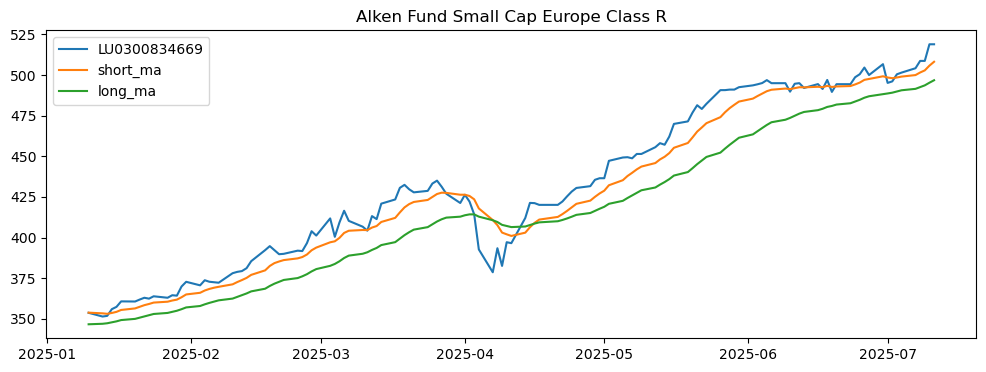

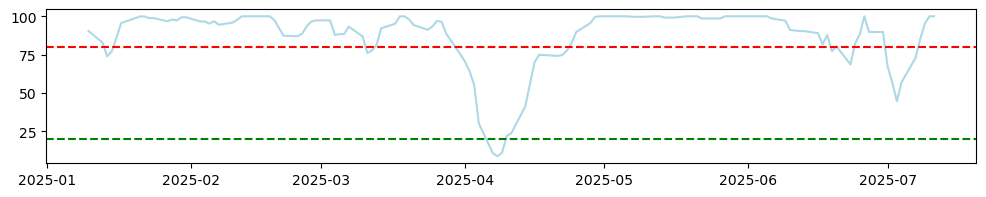

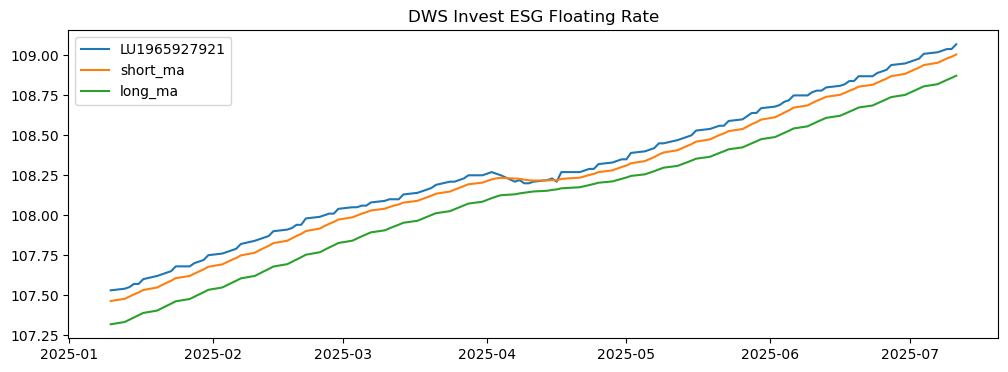

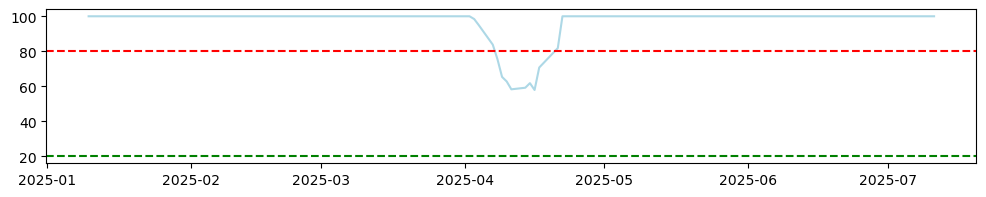

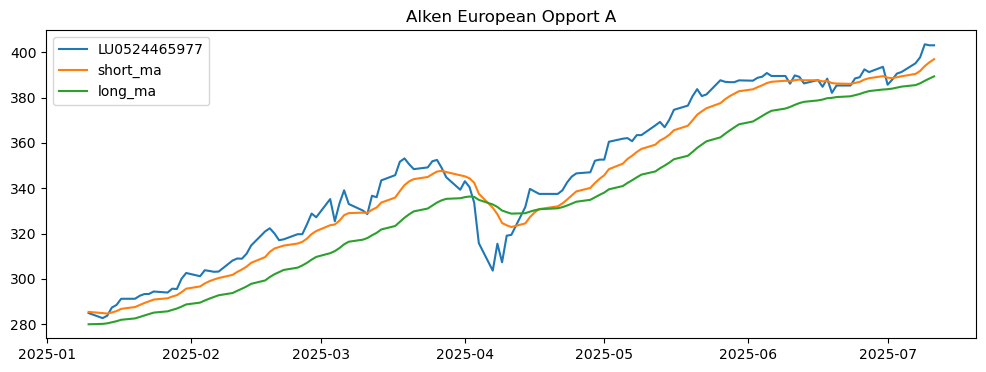

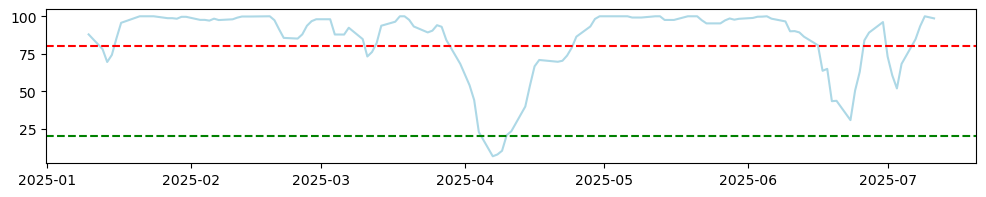

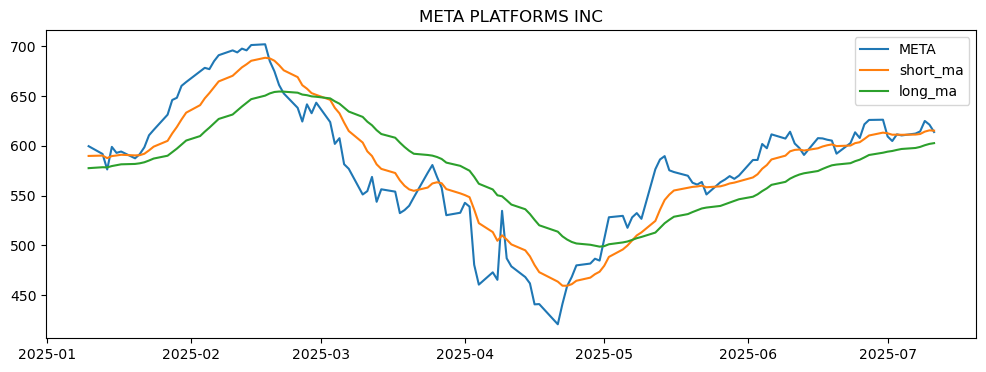

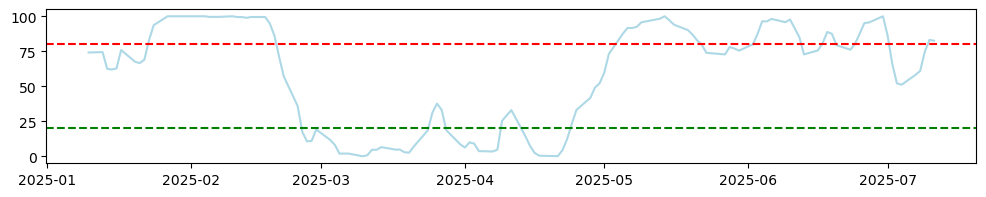

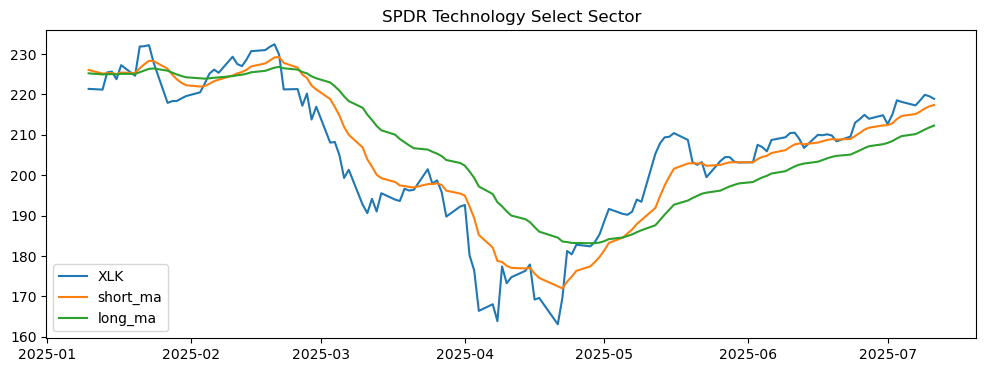

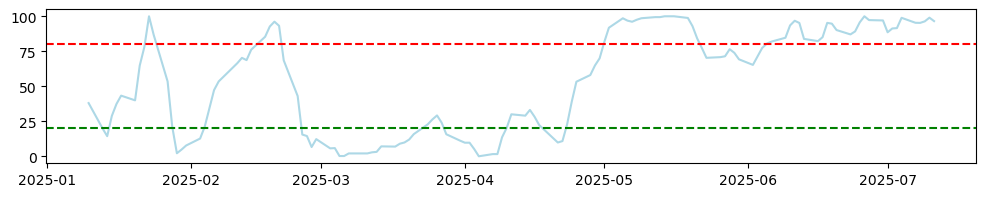

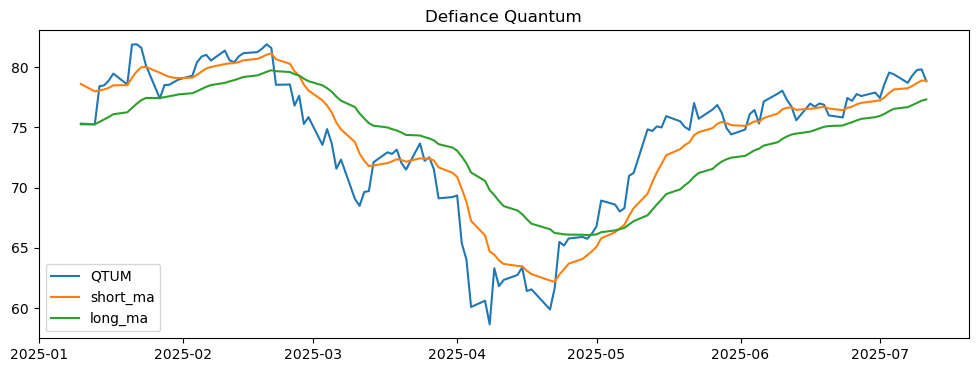

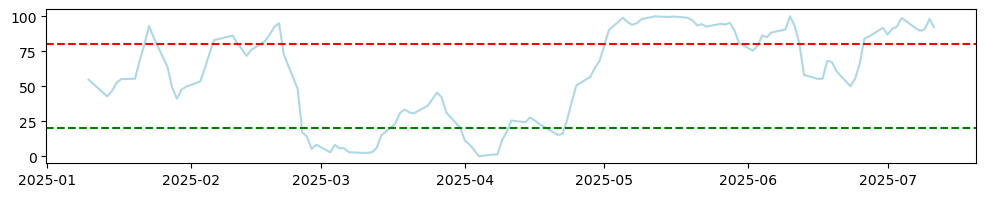

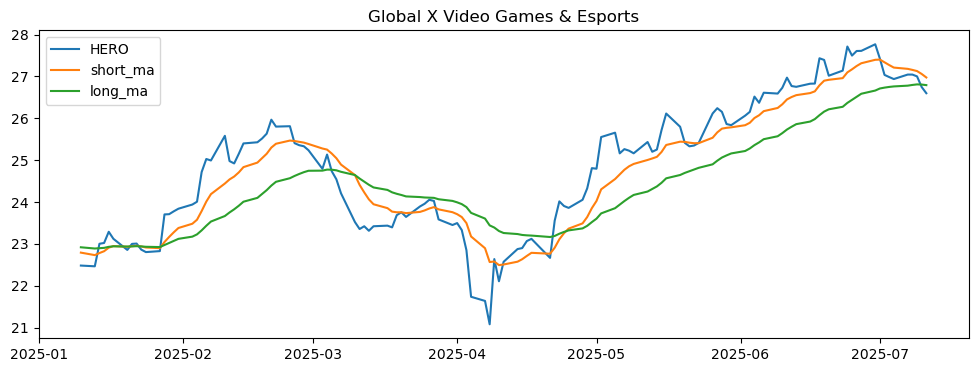

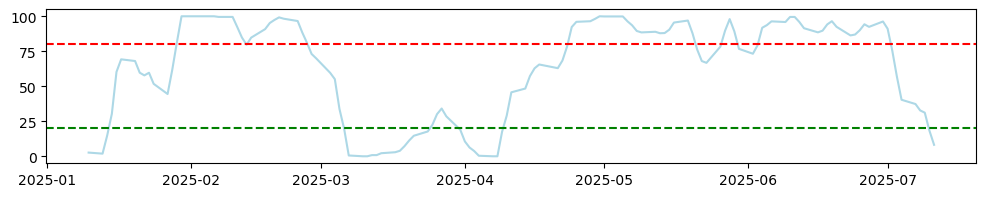

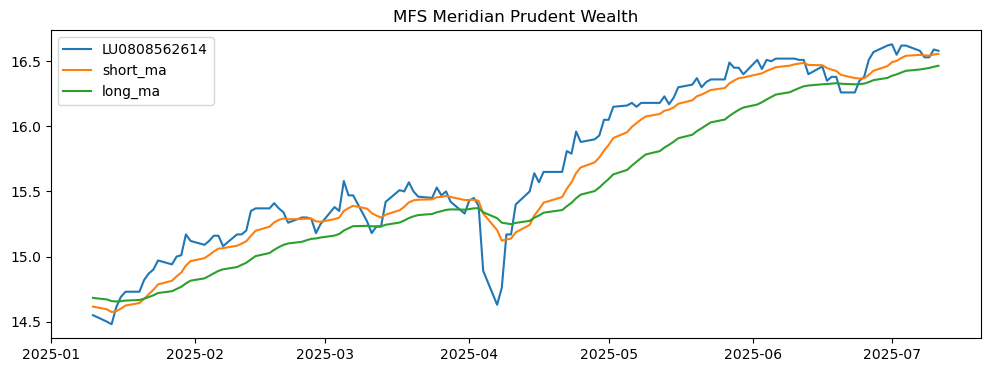

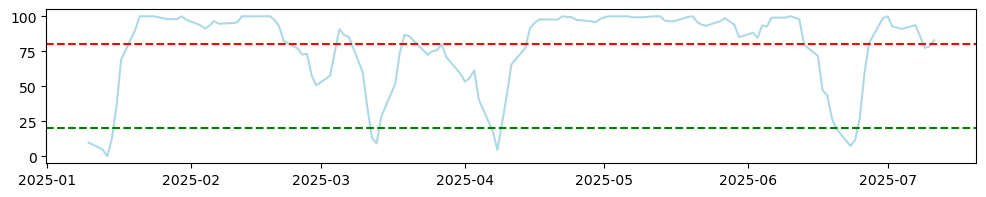

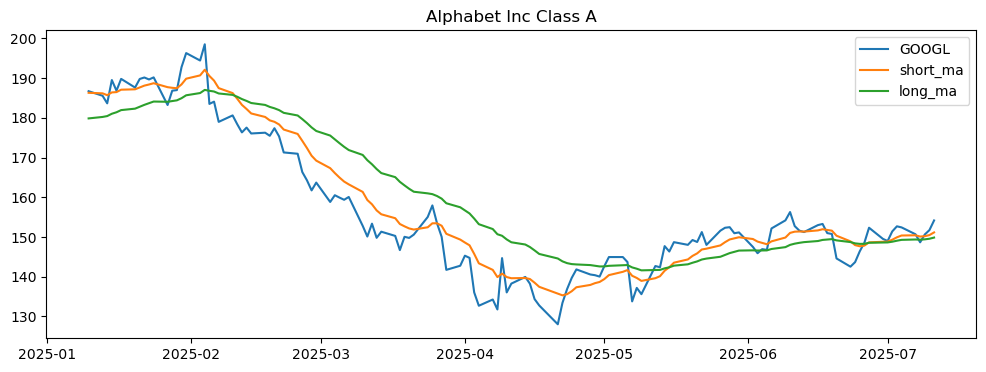

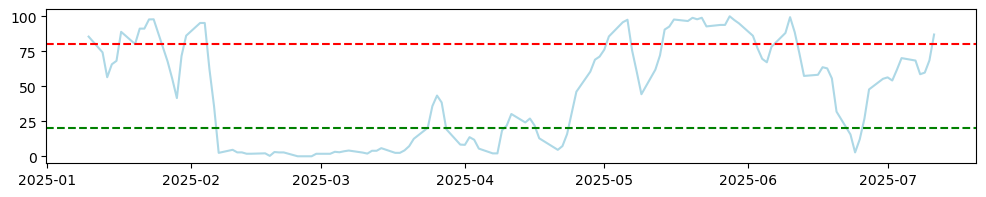

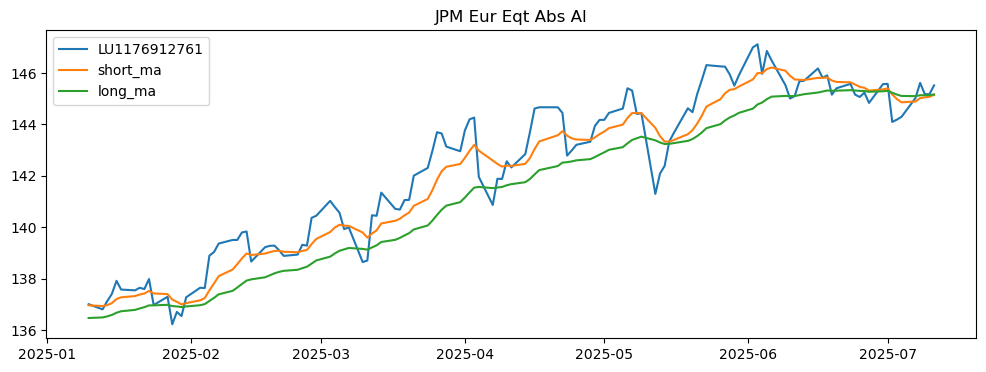

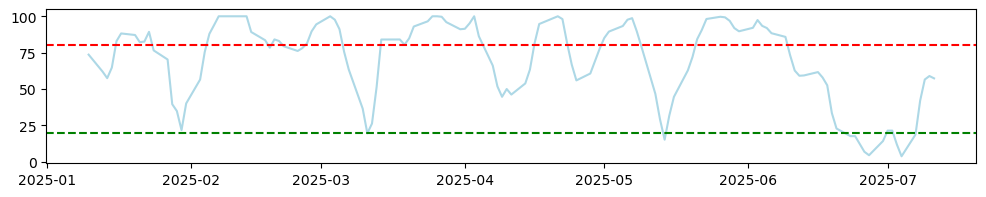

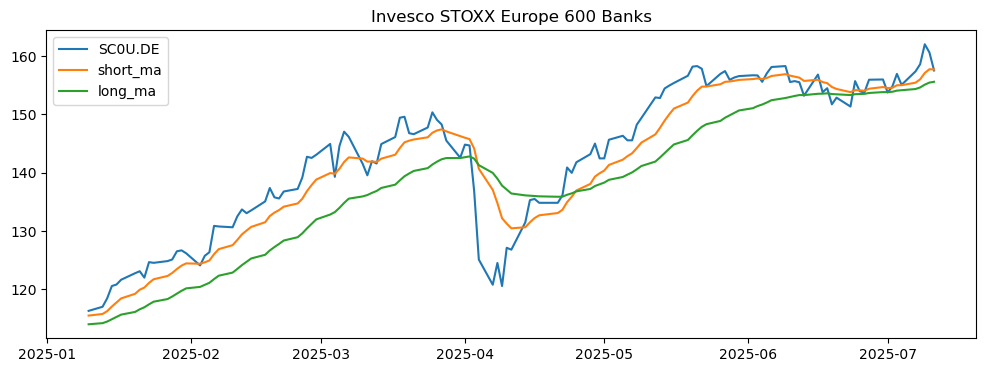

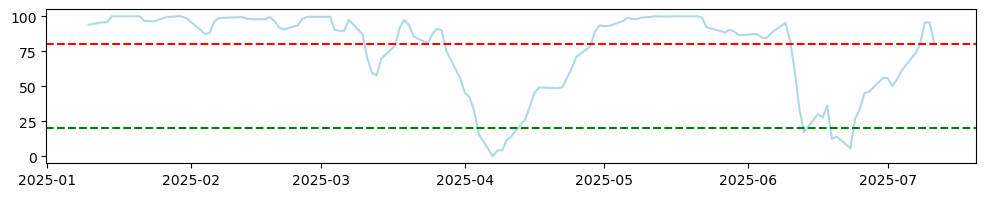

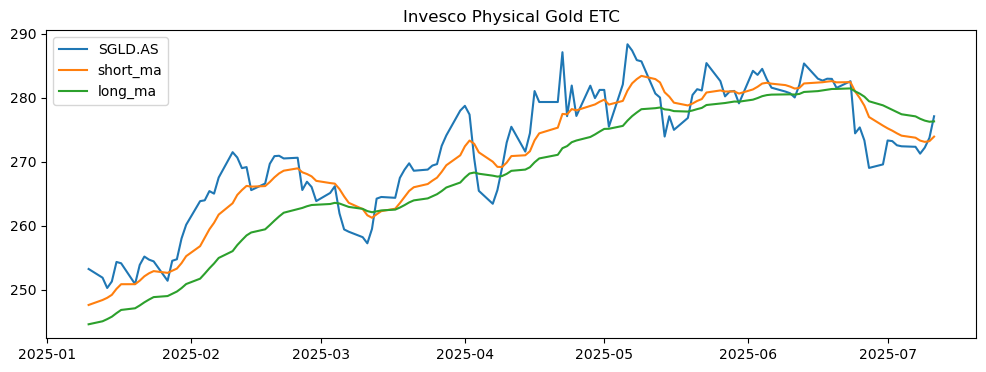

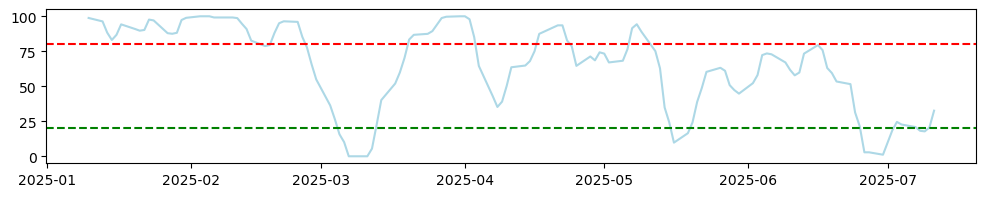

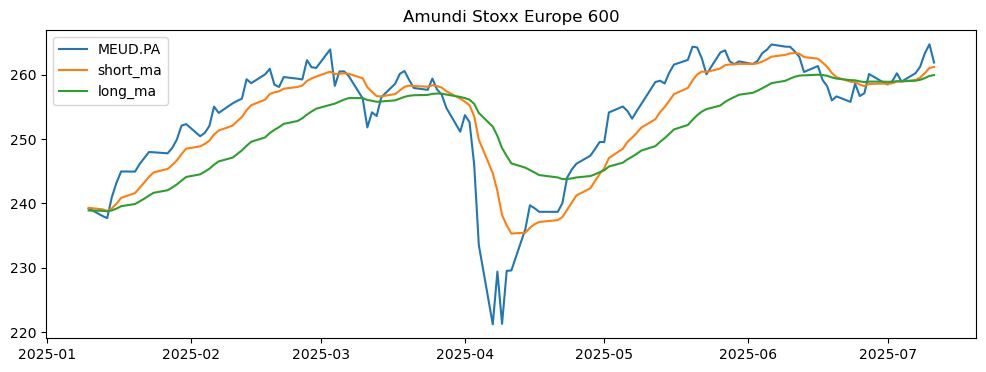

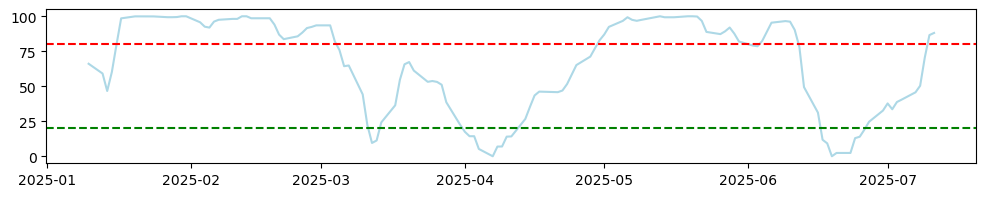

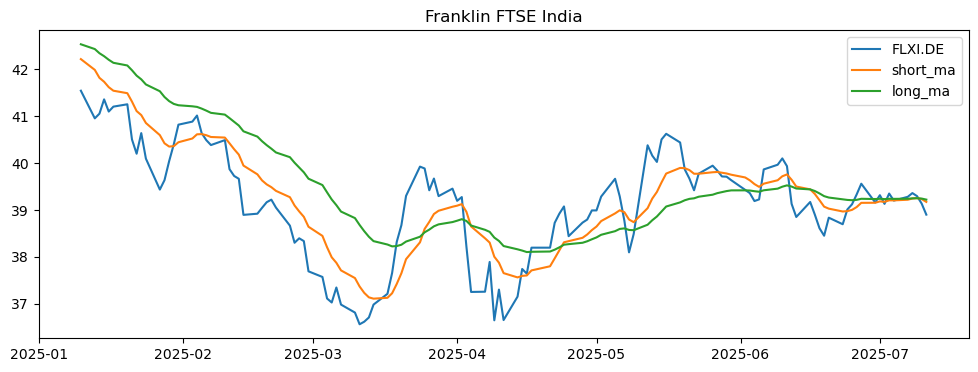

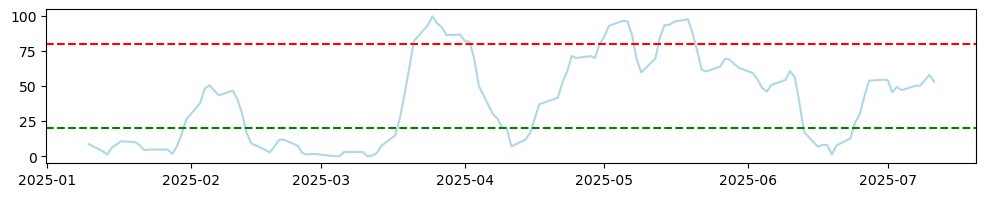

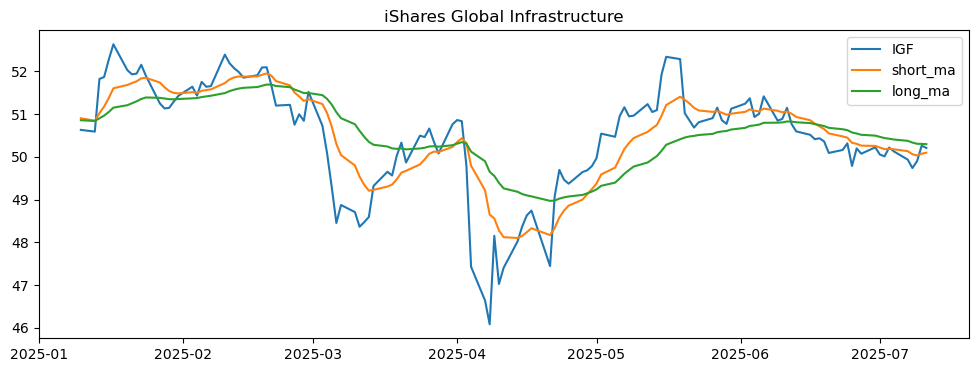

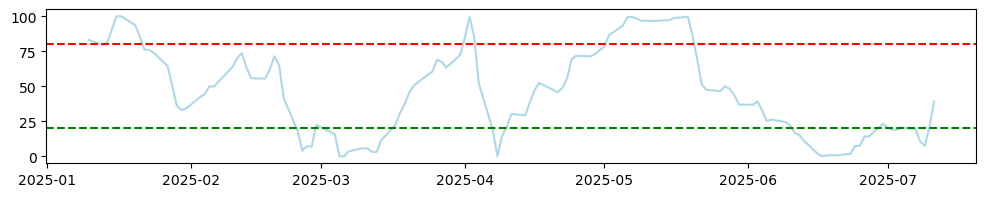

In [6]:

for symb in df_plot.index:
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

In [7]:
sell_opps(lag=5)


####################  SELL OPPS  #####################


Series([], Name: symb, dtype: object)

### Buy Opportunities

In [8]:
df_plot = df_features[df_features['Overbought Entry']].sort_values(by='Racio2',ascending=False)[:15]
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
XME,2.160148,0.019448,109.530078,0.006631,130.240702,0.846303,False,True,NaN
IPDM.L,2.263131,0.018335,121.794031,0.011653,107.256412,0.644905,False,True,NaN
LU2441282972,1.272591,0.020996,59.183682,0.005749,76.483715,0.526012,False,True,NaN
LU1705558135,0.234439,0.003555,57.514555,0.001357,65.221660,0.976447,False,True,NaN
LU0586678897,0.220005,0.003992,47.593767,0.001105,61.278969,0.986614,False,True,NaN
SC0V.DE,0.704728,0.014060,47.989561,0.005013,56.025990,0.961569,False,True,NaN
WELL.L,0.773208,0.016690,44.530314,0.005572,53.401776,0.507055,False,True,NaN
LU0255977539,0.881199,0.019806,42.977268,0.006726,51.188035,0.396447,False,True,NaN
LU0605625556,0.101909,0.001922,37.412037,0.000521,48.531386,0.954762,False,True,NaN
LU0348784397,0.537886,0.014233,35.684744,0.004014,45.629861,0.866732,False,True,NaN


XME 


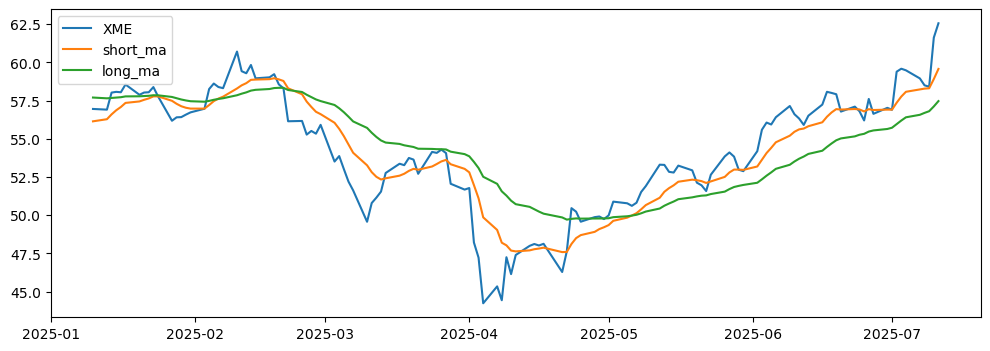

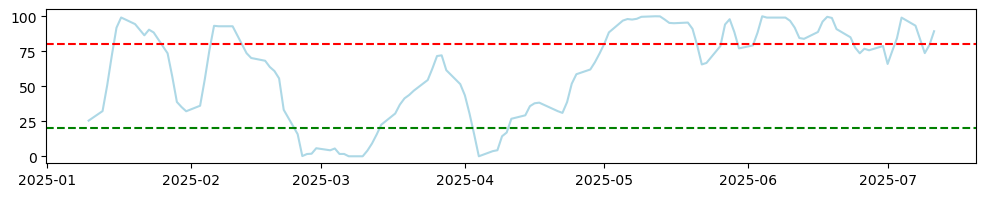

IPDM.L 


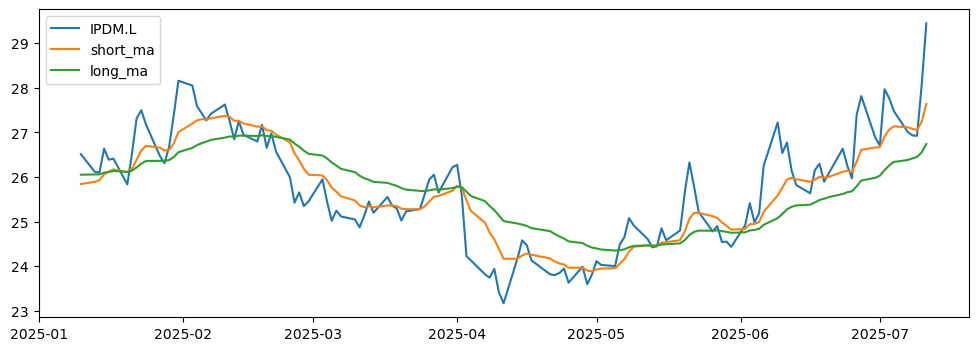

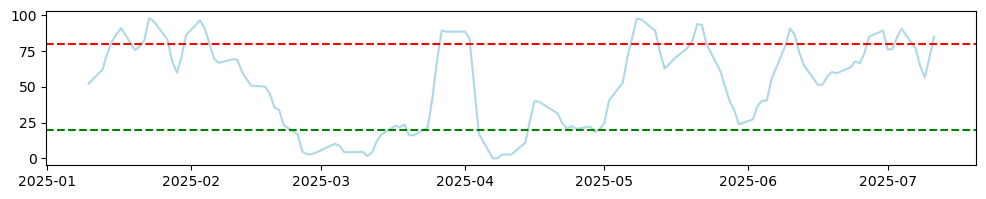

LU2441282972 


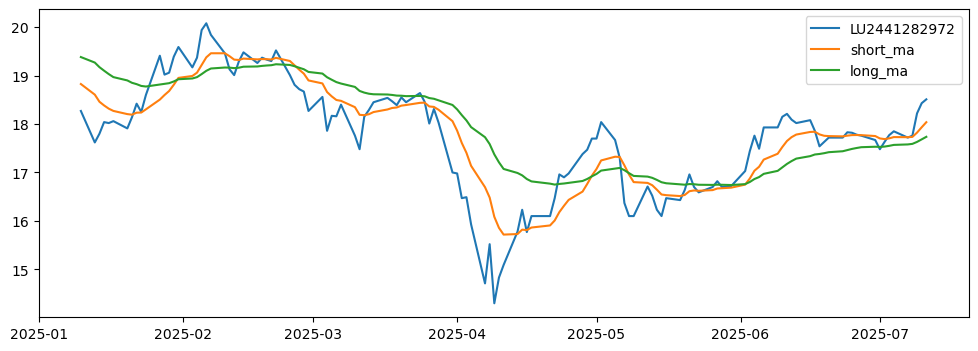

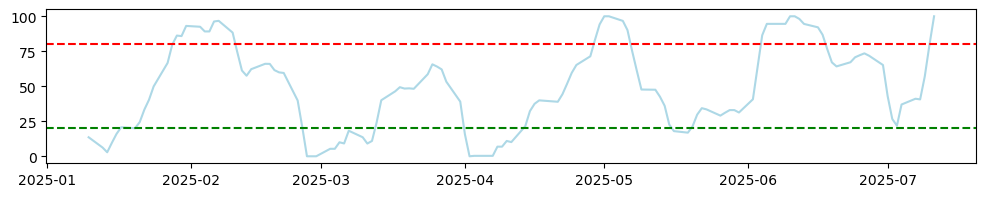

LU1705558135 


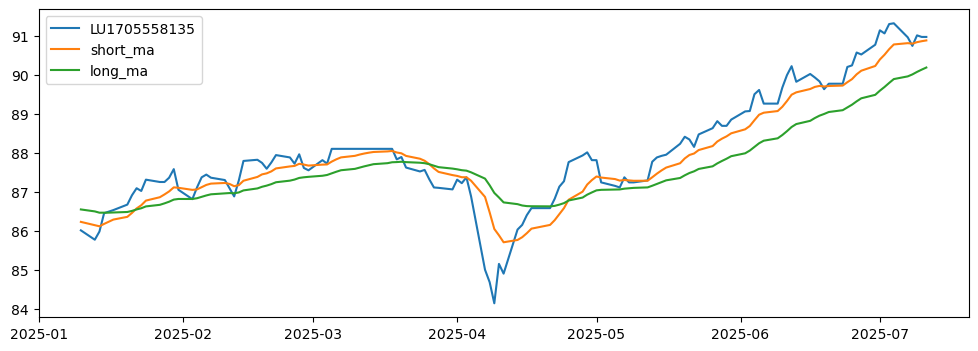

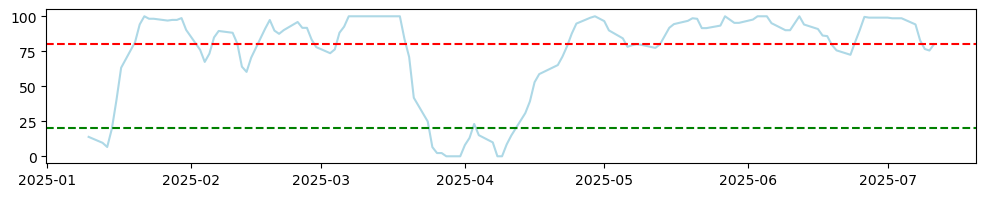

LU0586678897 


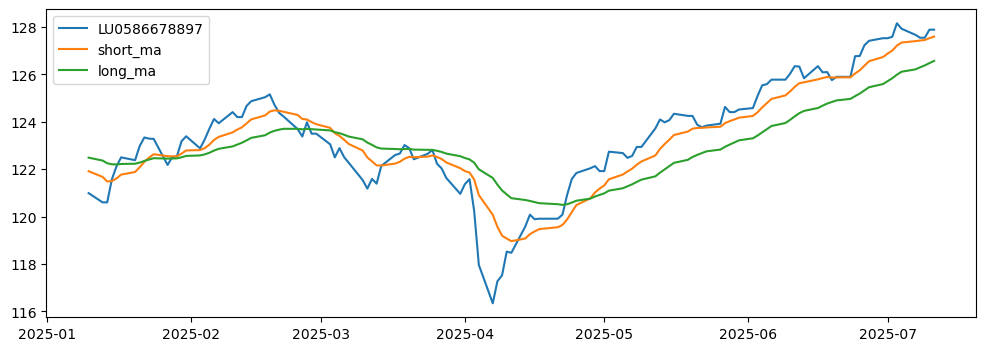

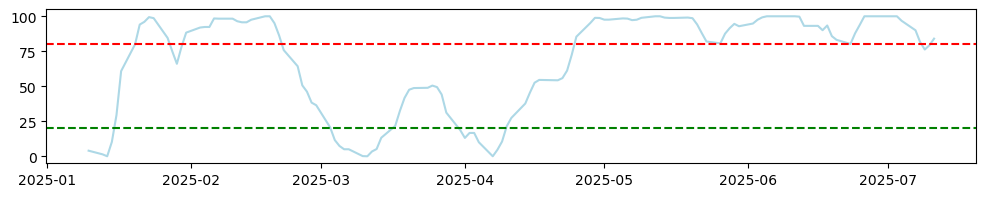

SC0V.DE 


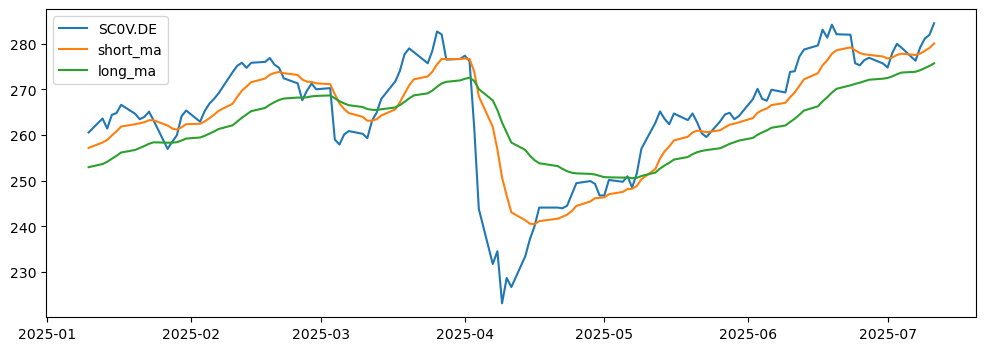

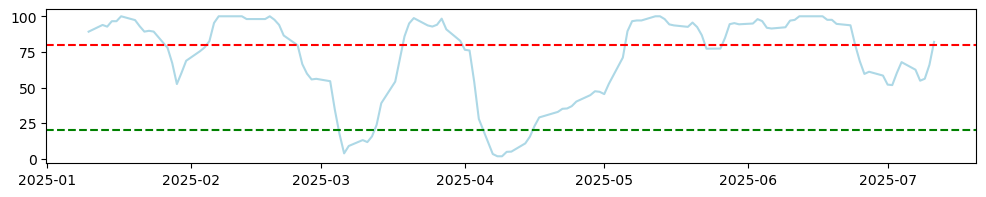

WELL.L 


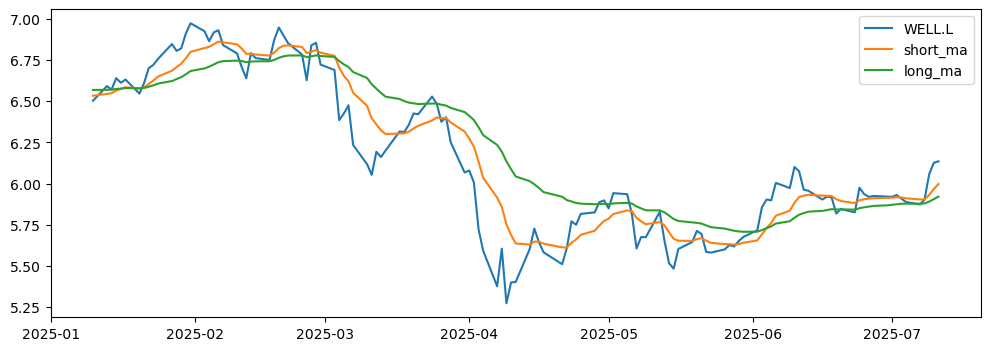

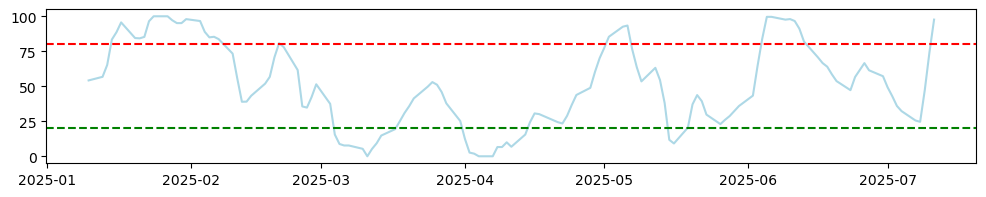

LU0255977539 


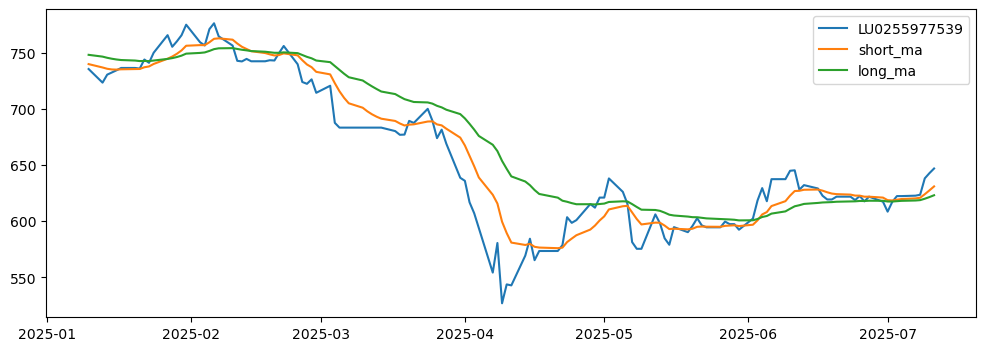

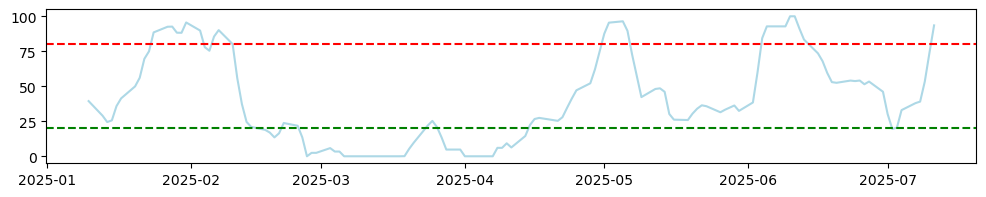

LU0605625556 


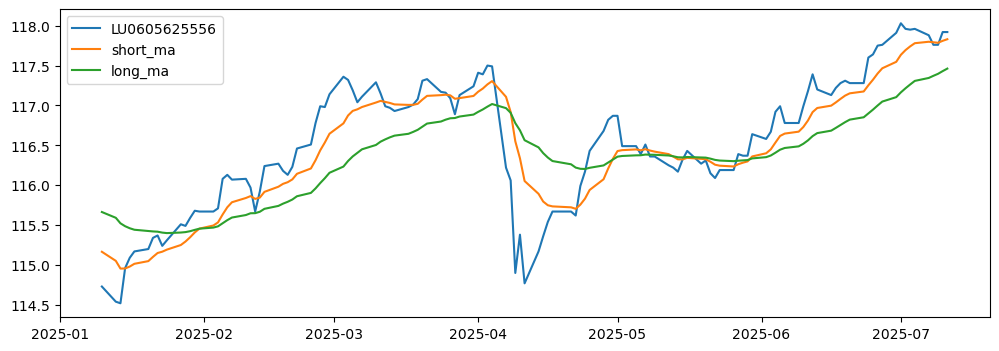

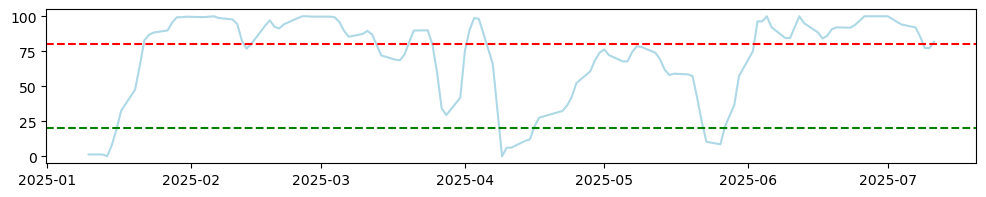

LU0348784397 


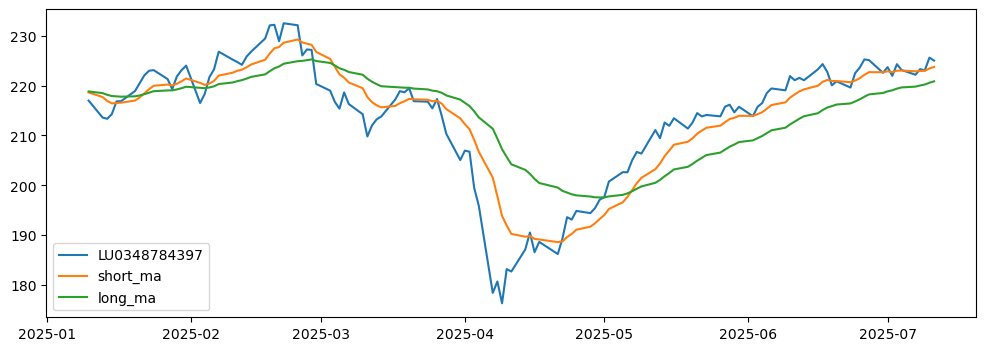

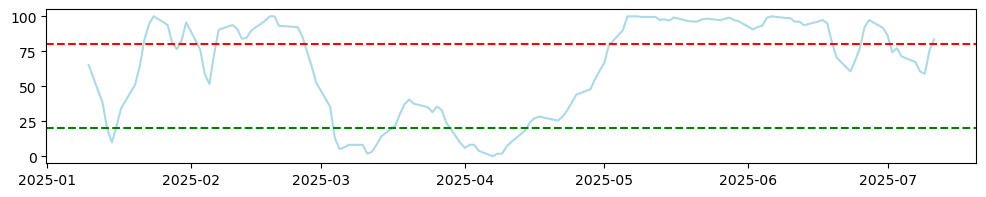

LU0198719832 


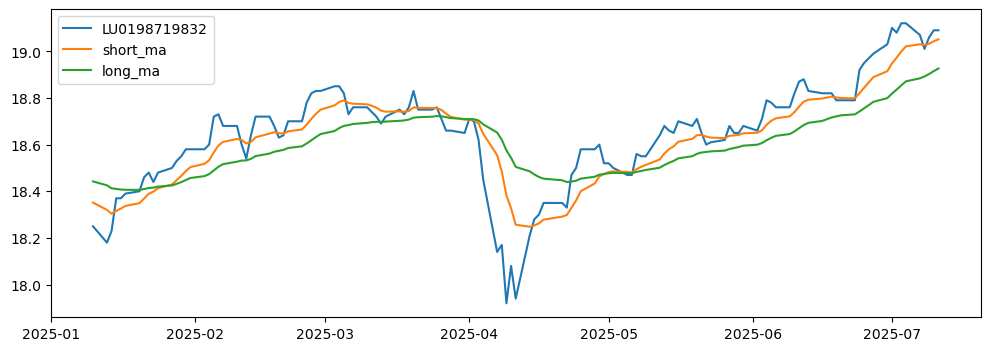

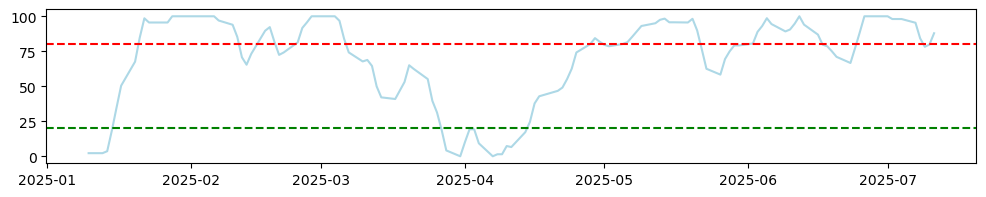

LU2441282899 


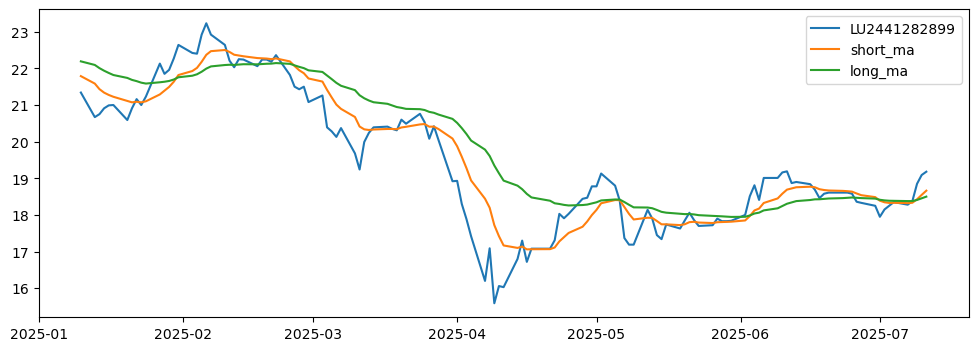

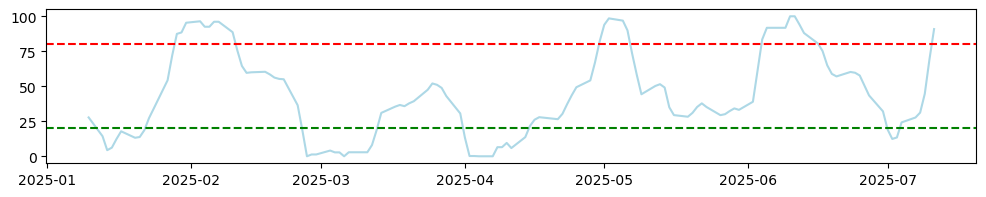

LU0806867908 


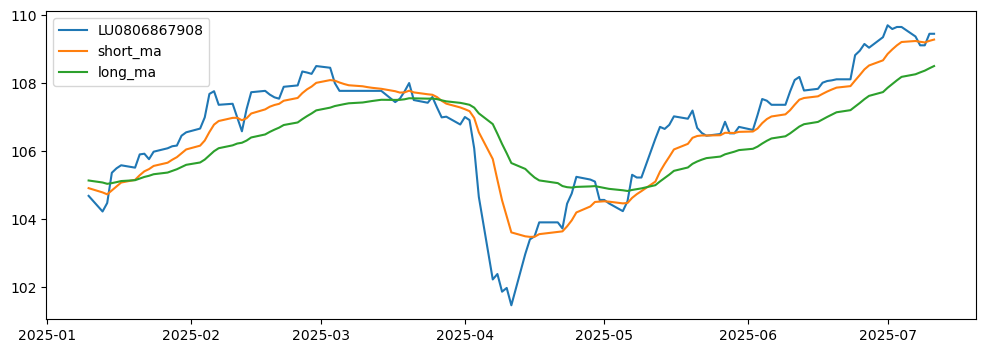

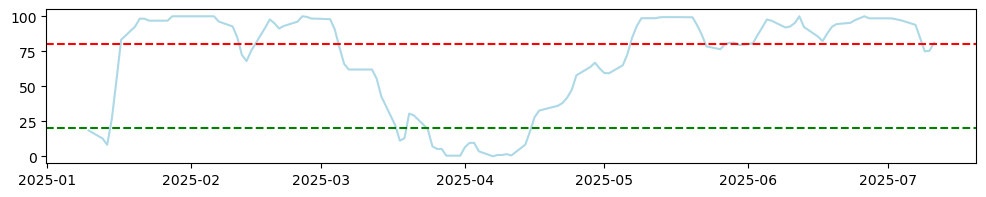

LU1897414303 


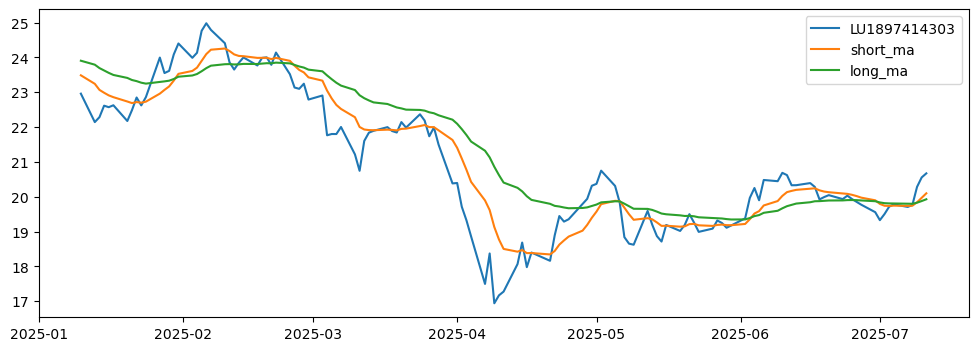

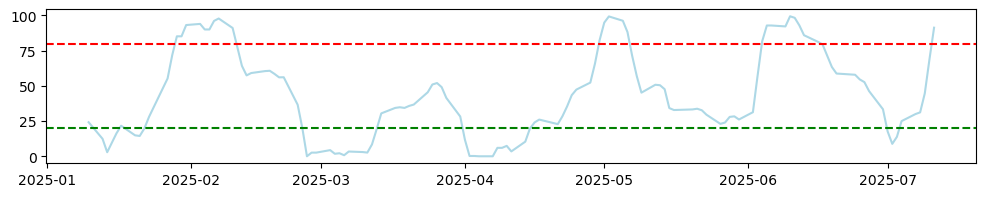

LU1644441120 


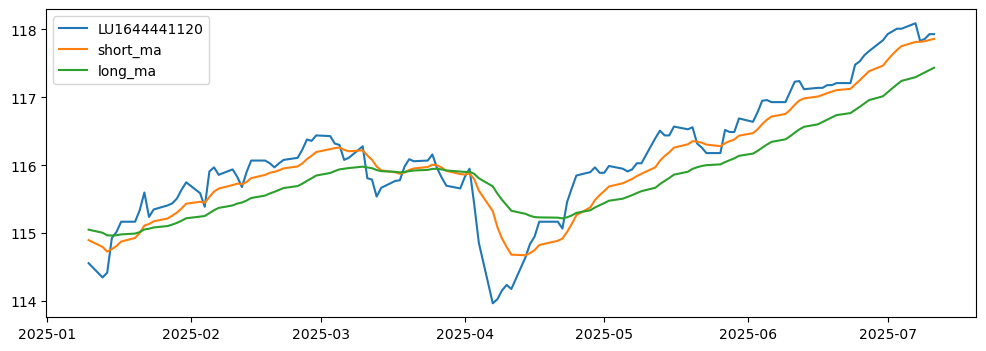

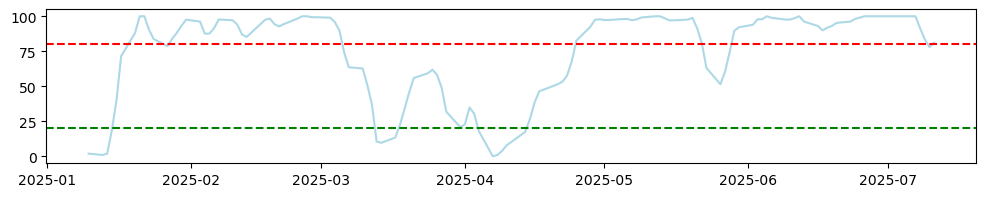

In [9]:

for symb in df_plot.index:
    print(symb,code2name_dict.get(symb,''))
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

In [23]:
def normalize(ds: pd.Series) -> pd.Series:
    # Calculate the IQR to detect high outliers
    Q1 = ds.quantile(0.25)
    Q3 = ds.quantile(0.75)
    IQR = Q3 - Q1

    # Define upper bound for high outliers (outliers above this value will be removed)
    upper_bound = Q3 + 100 * IQR

    # Filter data: keep values below the upper bound
    return ds[ds <= upper_bound]

df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['Growth']>0.15) & (df_features['Growth']<0.9)
#df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['Growth']>=0.04) & (df_features['Growth']<0.15)
#df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['D_Volat']>0.0005)
#df_filter =  (df_features['Growth']>=.2) #& (df_features['Growth']<0.07)

df_plot = df_features[df_filter].sort_values(by=['PricePosition', 'Racio2'], ascending=[False, False]).head(15)
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
LU0857130511,0.575848,0.007884,69.237848,0.001904,93.373021,1.0,False,False,NaN
LU1308313201,0.776564,0.011604,64.337963,0.002563,89.246373,1.0,False,False,NaN
LU1375654800,0.462369,0.005805,74.477127,0.002315,82.868115,1.0,False,False,NaN
LU0476877054,0.708705,0.012891,52.647514,0.002071,79.689021,1.0,False,False,NaN
LU1402171232,0.338793,0.004907,62.931067,0.001443,79.258654,1.0,False,False,NaN
IE00BZ199N67,0.898558,0.013389,64.872081,0.004320,78.854130,1.0,False,False,NaN
IE00BZ199P81,0.898558,0.013564,64.031896,0.004512,76.901200,1.0,False,False,NaN
LU1919971074,0.306105,0.005444,50.717345,0.001004,74.095559,1.0,False,False,NaN
LU0352097199,0.551963,0.009072,57.532810,0.003116,68.211960,1.0,False,False,NaN
LU1163203471,0.170850,0.003312,42.530104,0.000471,66.235939,1.0,False,False,NaN


LU0857130511 


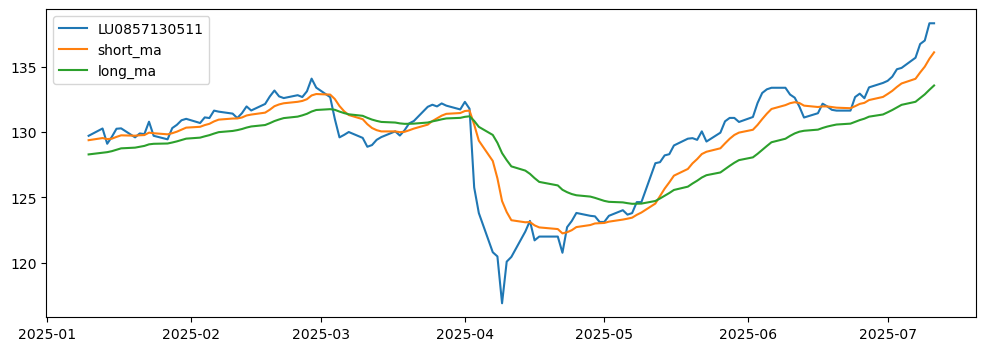

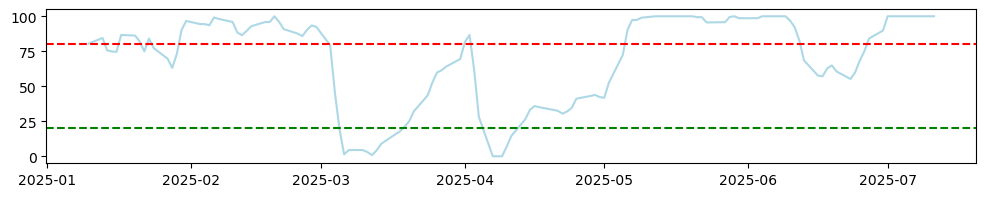

LU1308313201 


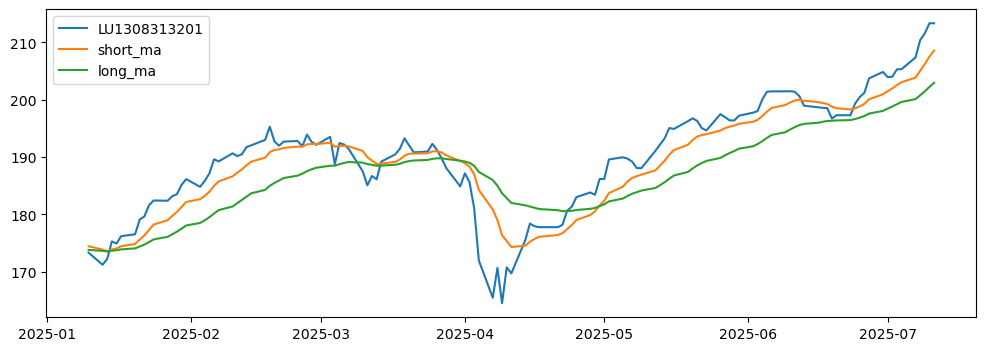

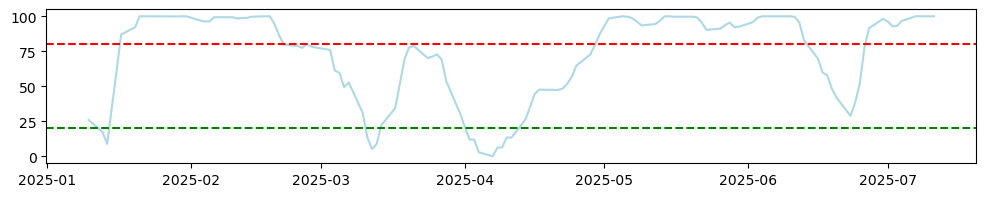

LU1375654800 


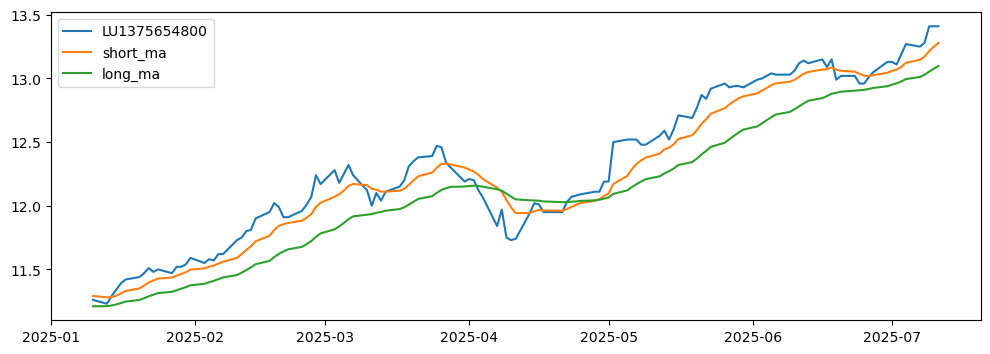

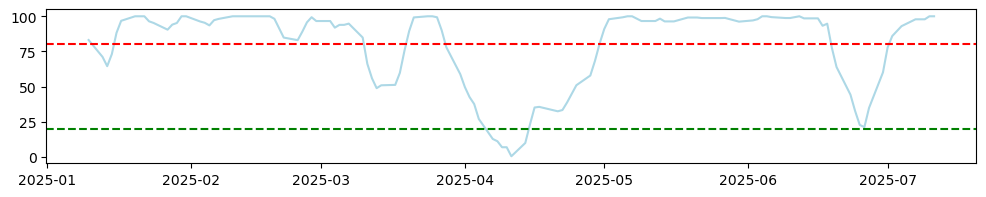

LU0476877054 


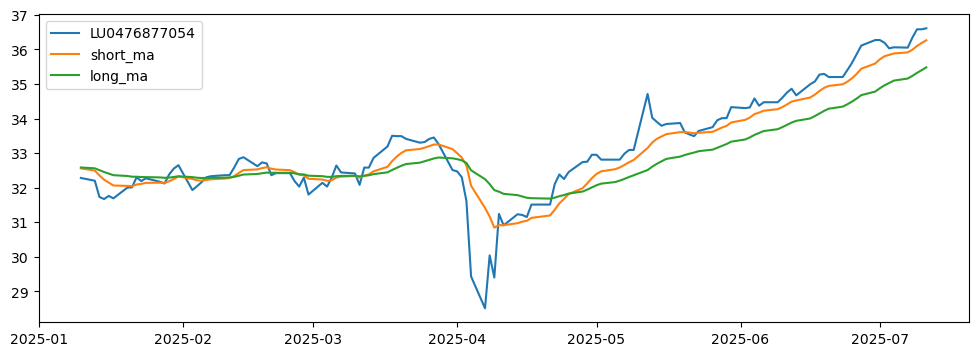

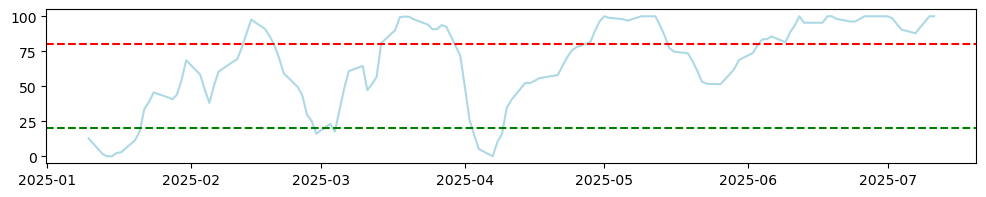

LU1402171232 


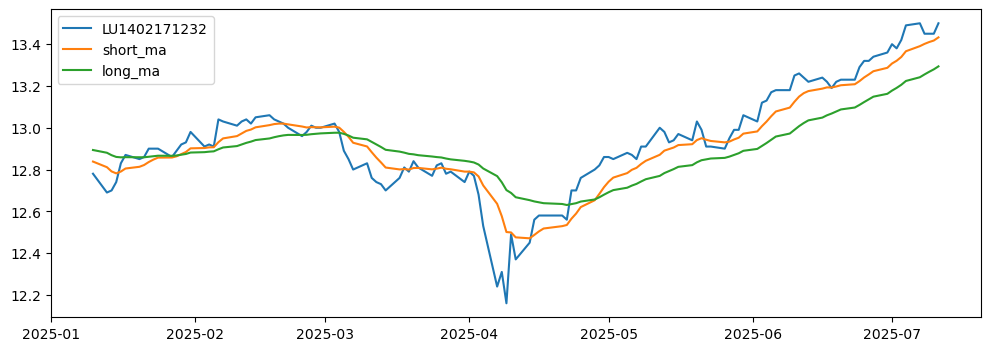

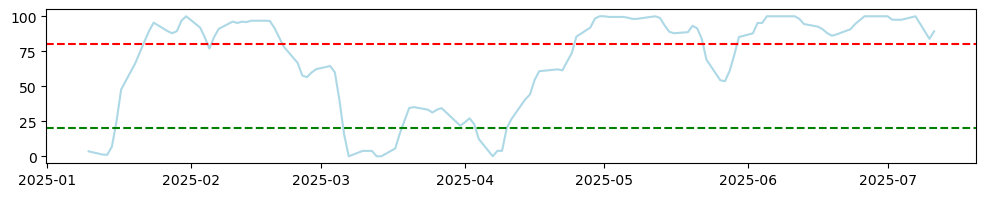

IE00BZ199N67 


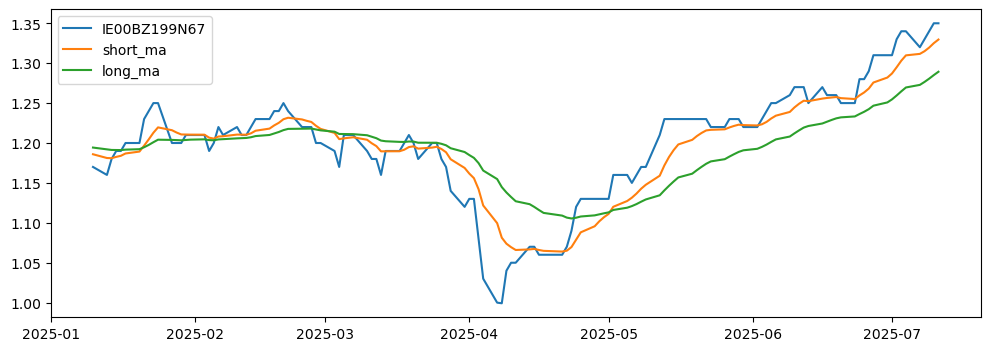

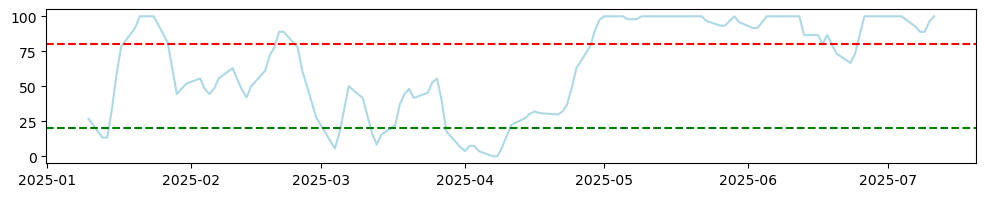

IE00BZ199P81 


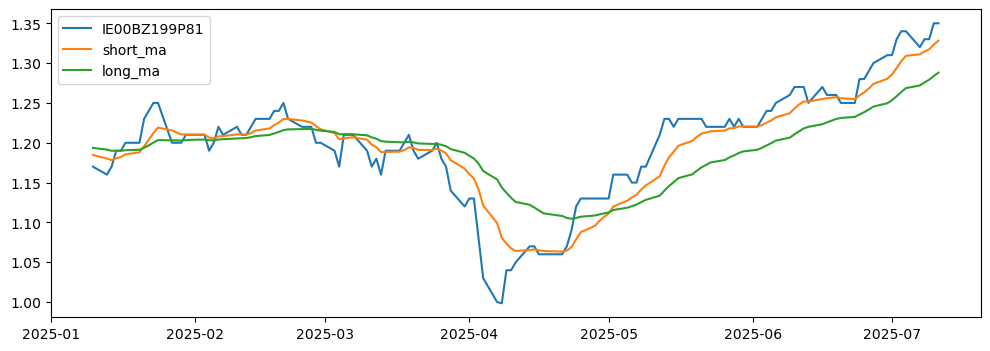

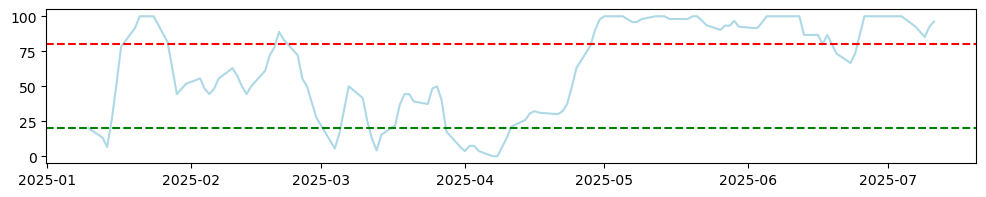

LU1919971074 


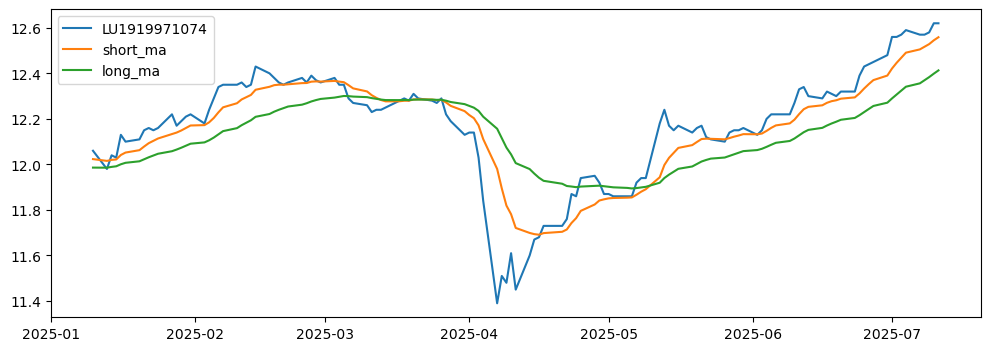

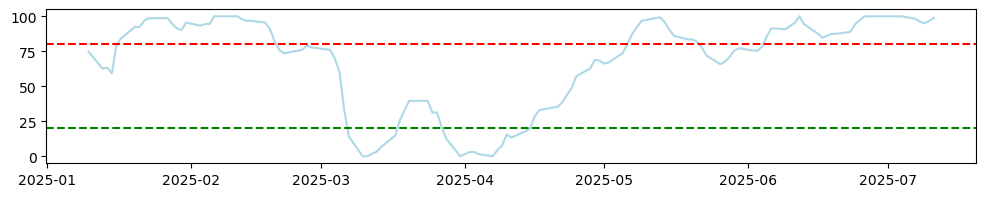

LU0352097199 


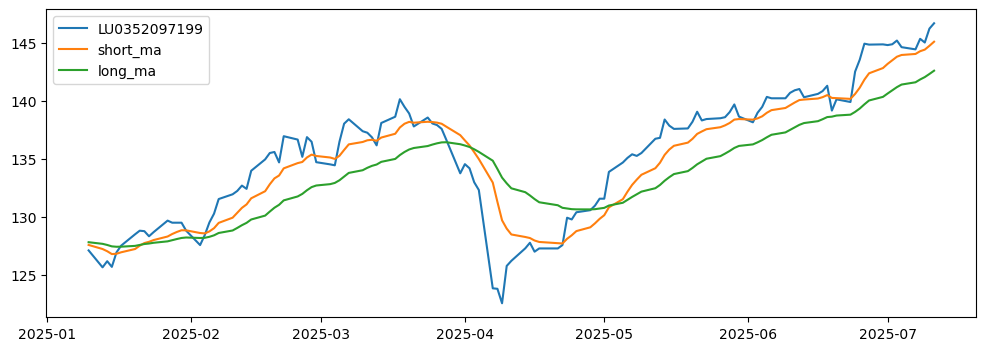

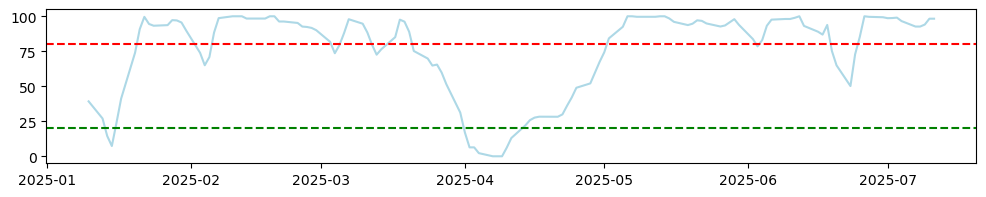

LU1163203471 


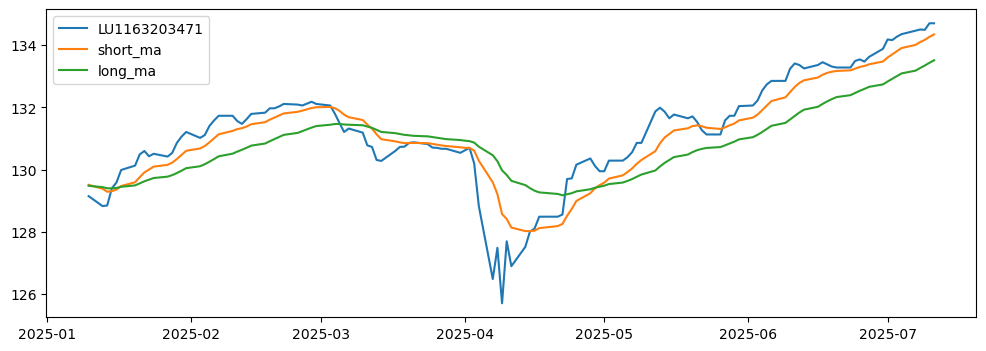

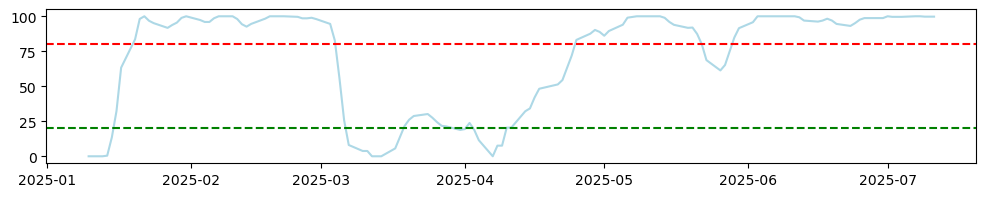

LU1328849515 


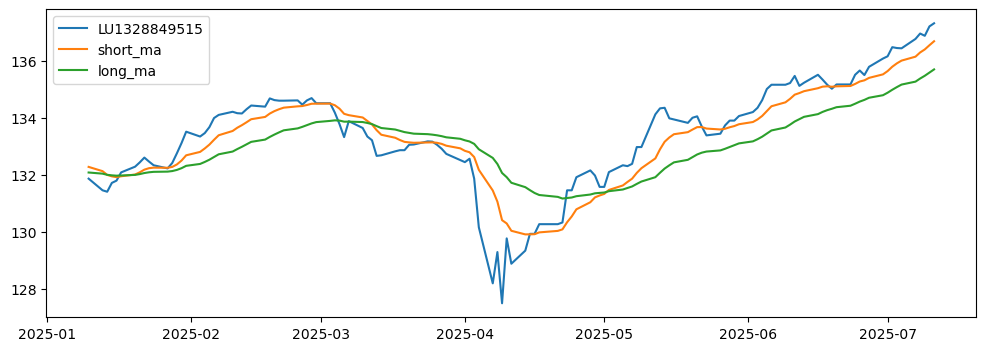

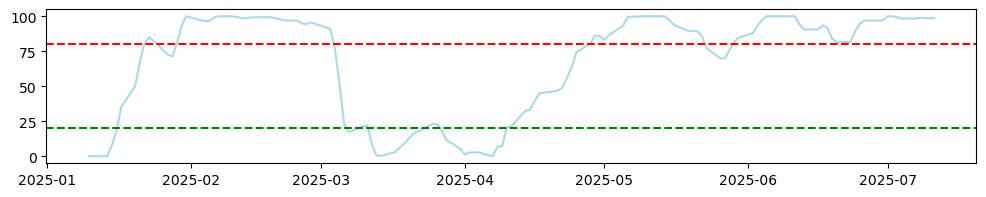

IE00BHPRMV90 


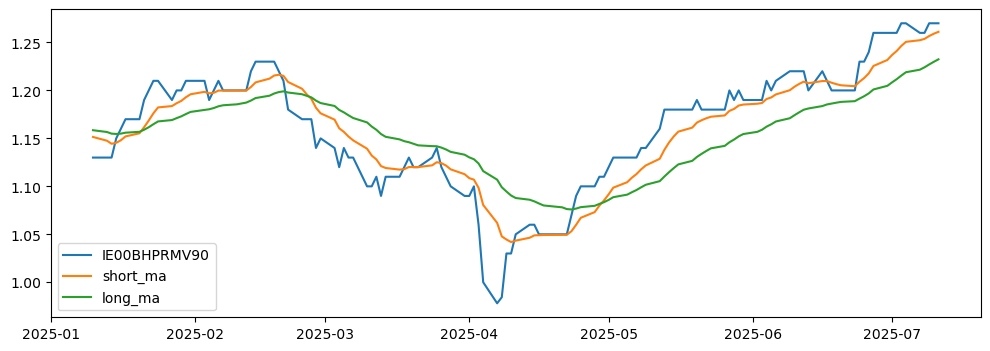

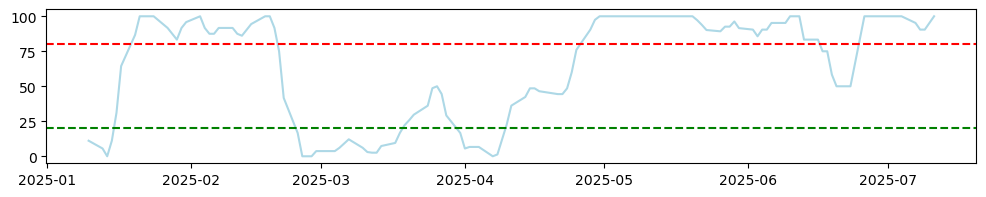

LU1914905929 


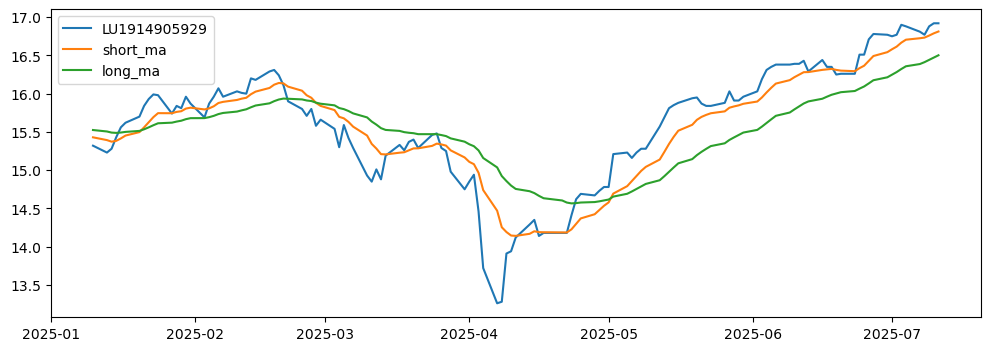

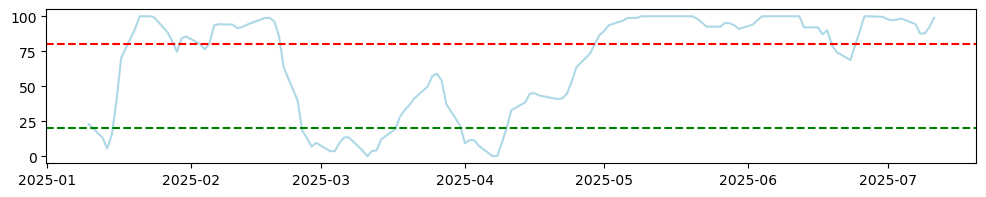

LU0563745743 


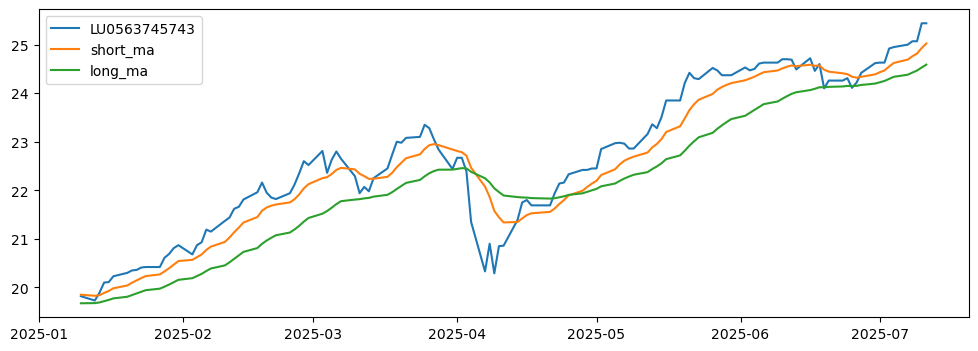

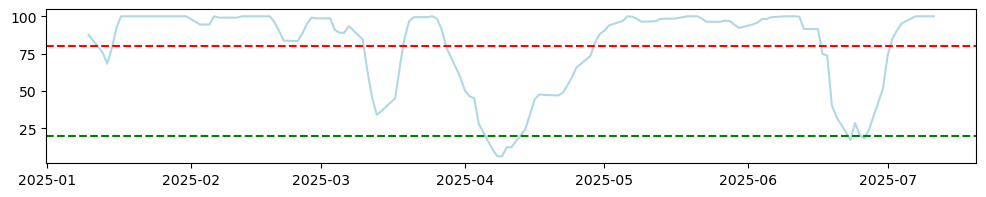

IE00B8W3L103 


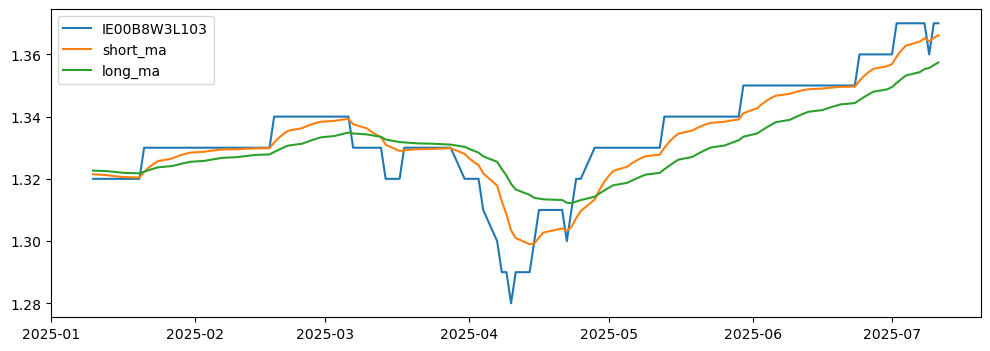

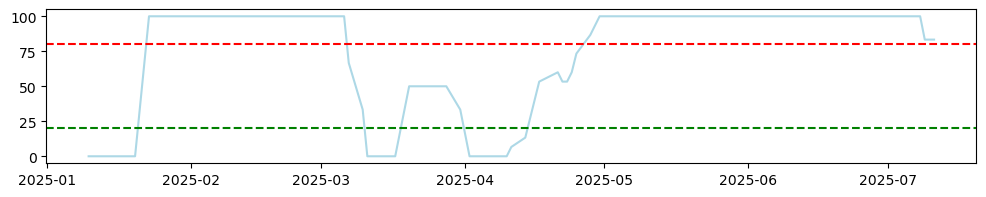

In [24]:

for symb in df_plot.index:
    print(symb,code2name_dict.get(symb,''))
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

In [14]:
df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['STD']>0.005)

df_plot = df_features[df_filter].sort_values(by='Racio2',ascending=False).head(15)
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
XPPE.DE,7.701341,0.016570,462.973239,0.011999,378.191462,0.941426,False,False,NaN
IPLT.L,6.072156,0.016320,370.220751,0.011966,300.211979,0.959374,False,False,NaN
XPPT.DE,5.918821,0.016103,365.697863,0.011597,299.706693,0.950816,False,False,NaN
LU1861217831,3.726268,0.021201,174.343589,0.004964,237.481400,0.973101,False,False,NaN
SOXL,12.091814,0.074685,161.502163,0.022975,199.970773,0.283650,False,False,NaN
URA,4.986971,0.028006,176.995633,0.012435,187.496028,0.917663,False,False,NaN
LU0301638341,2.962448,0.017481,167.747129,0.006905,187.424311,1.000000,False,False,NaN
KRW.PA,2.220288,0.015058,145.458557,0.006466,156.511453,0.890788,False,False,NaN
JEDI.DE,3.242508,0.025348,126.738182,0.008711,150.225015,0.983713,False,False,NaN
XSLE.DE,2.066511,0.015674,129.925686,0.006056,146.579450,1.000000,False,False,NaN


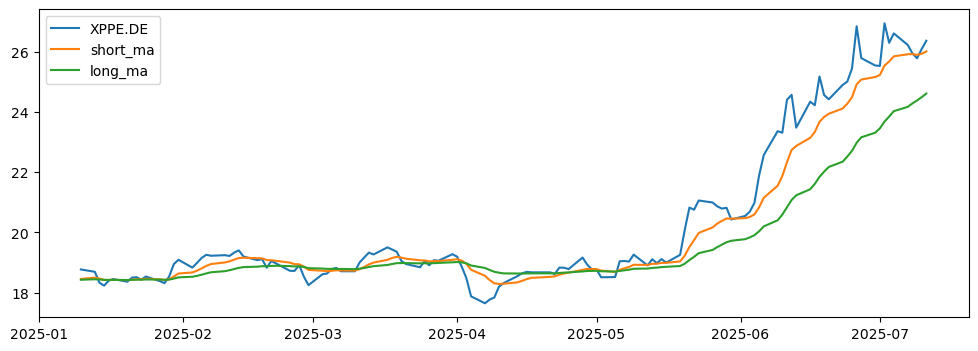

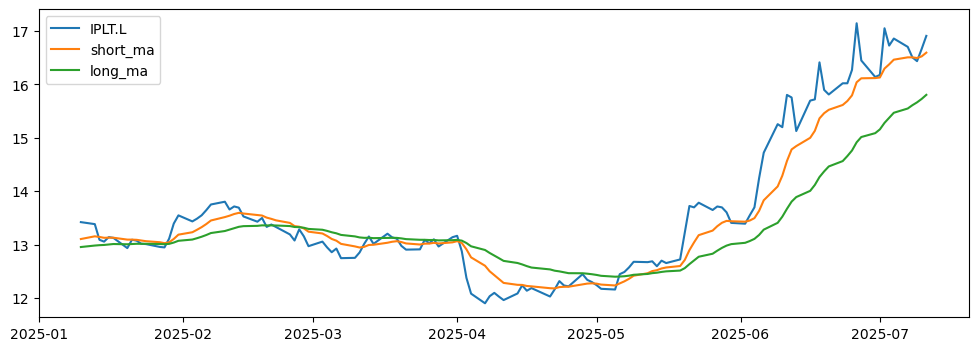

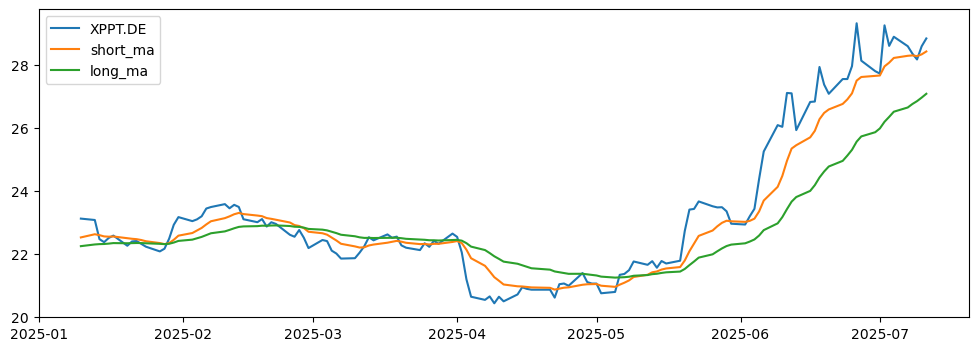

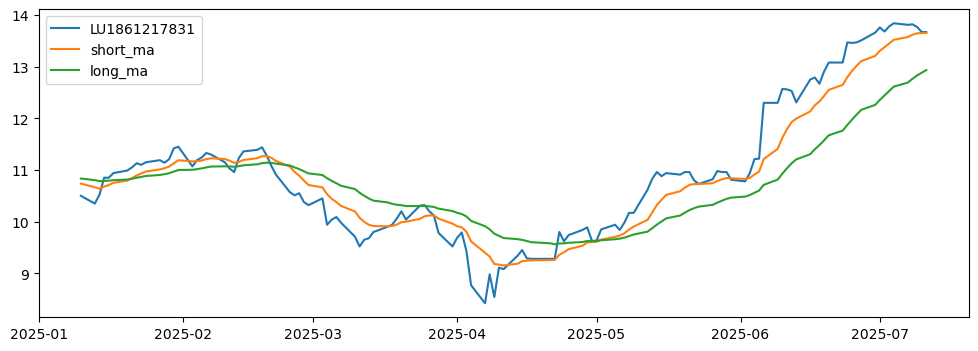

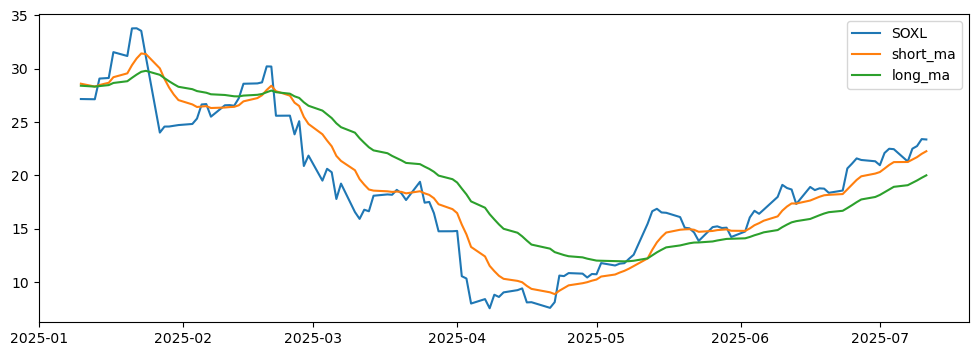

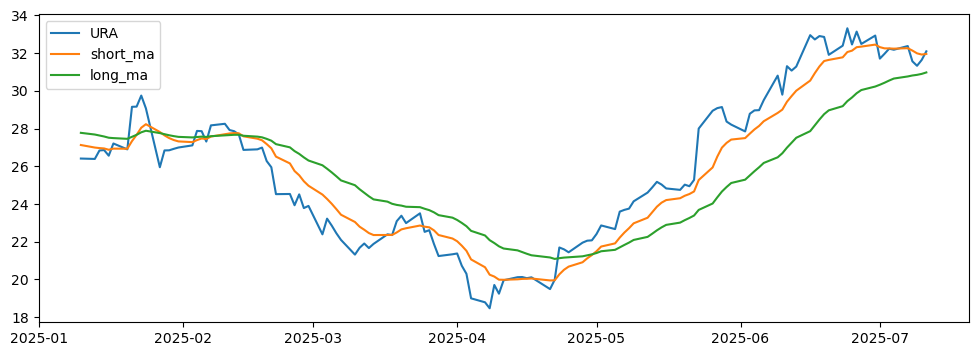

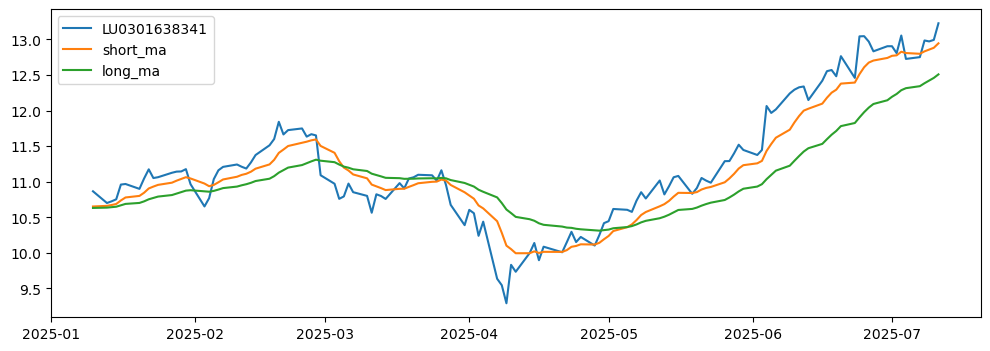

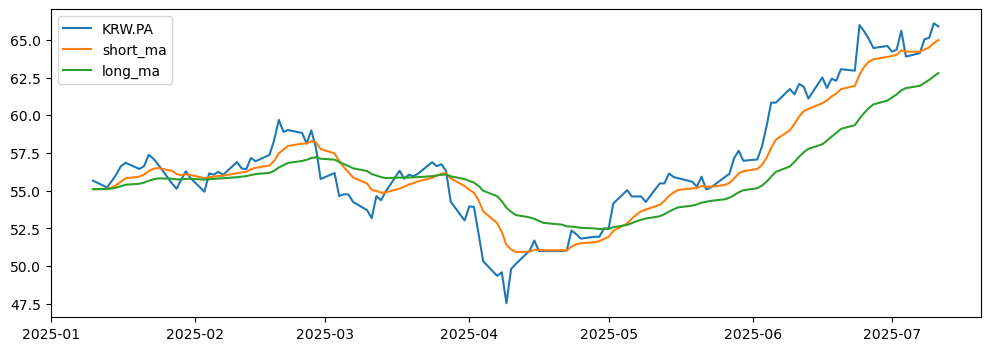

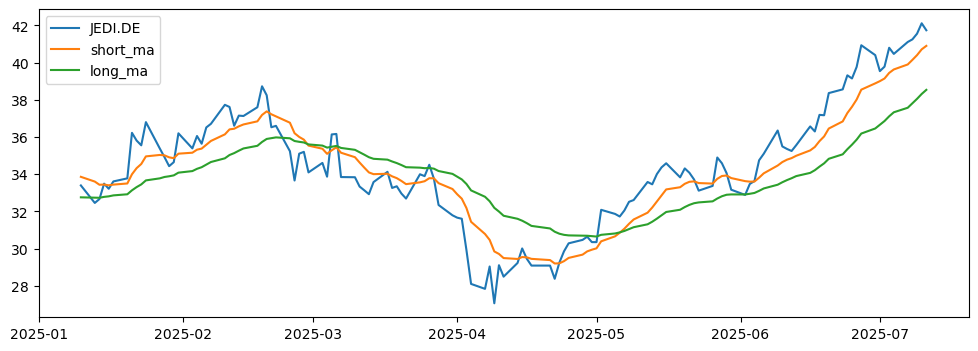

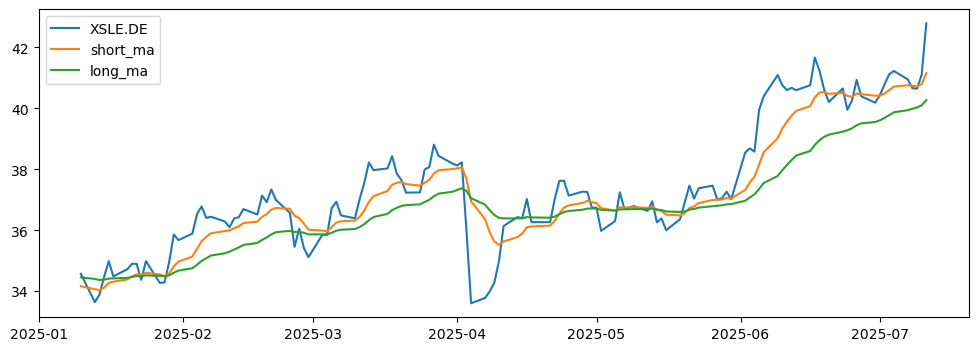

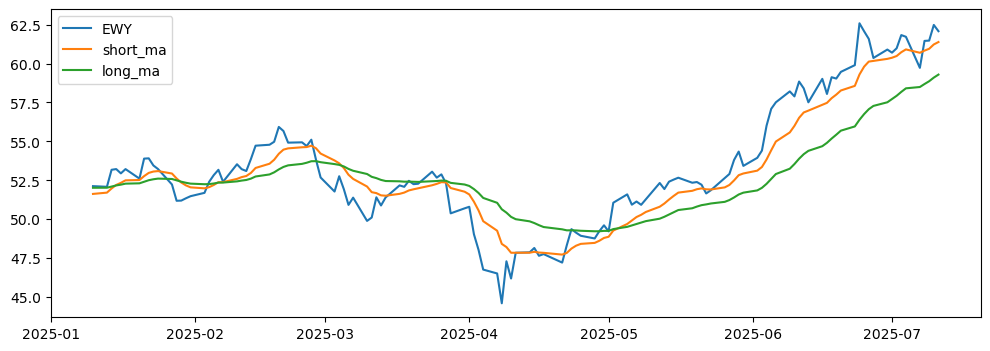

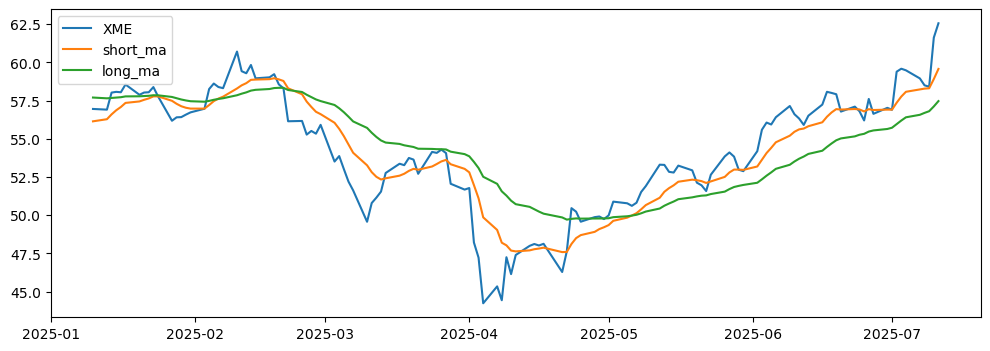

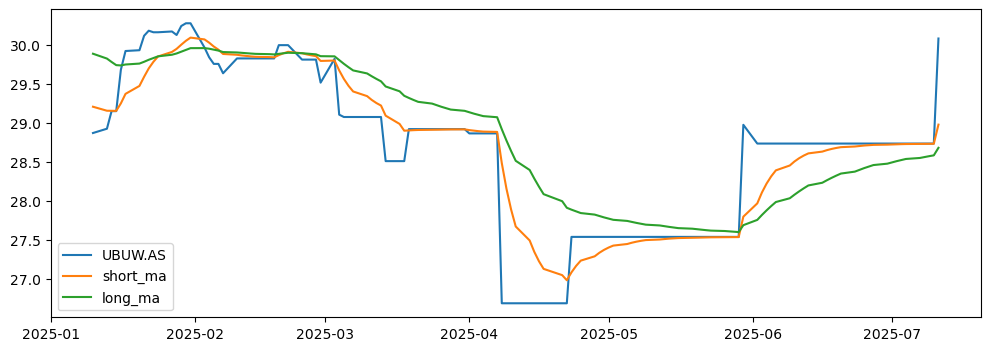

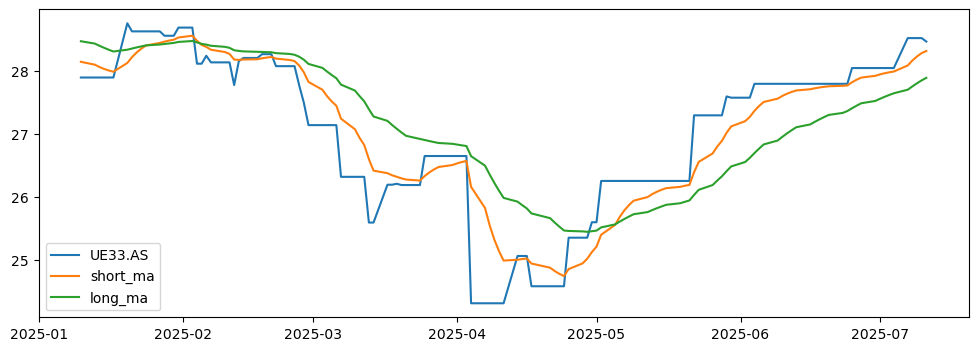

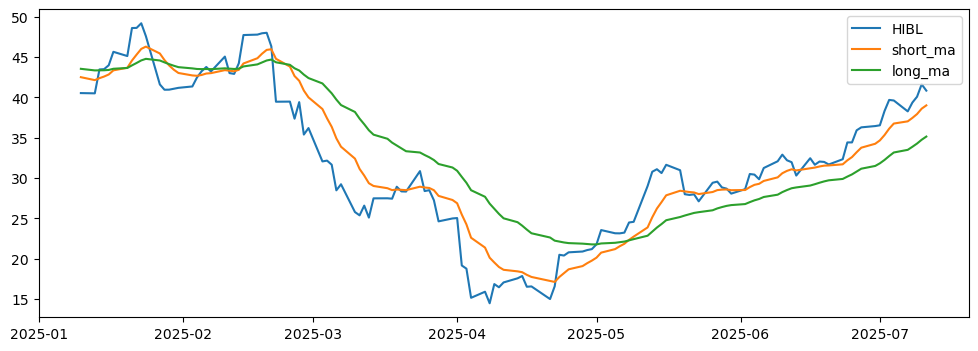

In [15]:

for symb in df_plot.index:
    print_fund_change(symb)

In [16]:
df_filter = df_features.index.isin(['LU1508158513'])
df_plot = df_features[df_filter].sort_values(by='Racio2',ascending=False).head(15)
df_plot


,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
LU1508158513,-0.133186,0.002482,-65.750381,0.002073,-49.239788,0.889811,False,False,NaN


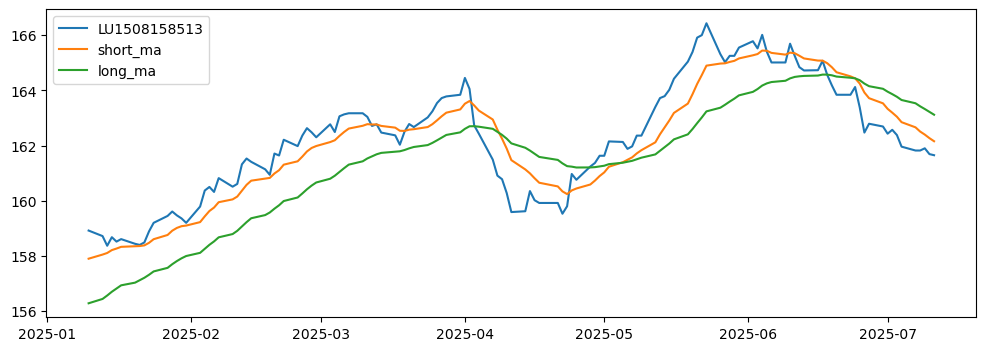

In [17]:
for symb in df_plot.index:
    print_fund_change(symb)

In [18]:
def calculate_correlations(single_series, df_timeseries):
    aligned_series, aligned_df = single_series.align(df_timeseries, join='inner', axis=0)
    
    # Step 2: Convert the aligned Series and DataFrame to NumPy arrays
    series_array = aligned_series.values  # 1D array (single time series)
    df_array = aligned_df.values  # 2D array (list of time series)
    
    # Step 3: Concatenate the single series as the first column with the DataFrame's time series
    combined_data = np.vstack([series_array, df_array.T])  # (n_time_series+1, n_dates) matrix
    
    # Step 4: Compute the correlation matrix using np.corrcoef (works on rows as variables)
    correlation_matrix = np.corrcoef(combined_data)
    
    # Step 5: Extract the correlations between the single series and each time series in the DataFrame
    # The correlation of the first row (single_series) with the remaining rows (df_timeseries)
    single_series_correlations = correlation_matrix[0, 1:]  # First row, excluding self-correlation
    
    # Step 6: Return the result as a Pandas Series with time series column names from df_timeseries
    result = pd.Series(single_series_correlations, index=aligned_df.columns, name='correlation')
    
    return result

def get_correlations():
    #find_top_correlated_pairs(df_quotes)
    corr_list = []

    # Ignore warnings only in this block
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for symb in relevant_etfs:
            df_tmp = pd.concat([df_quotes[symb].shift(1),df_quotes.drop(columns=[symb])],axis=1).apply(lambda x: x/x.shift(-1)).dropna()
            df_corr_tmp = calculate_correlations(df_tmp[symb], df_tmp.drop(columns=[symb])).dropna().reset_index().rename(columns={'index':'ts2'})
            df_corr_tmp = df_corr_tmp[df_corr_tmp['correlation'].apply(lambda x: abs(x)) >= 0.5]
            df_corr_tmp['ts1'] = symb
            corr_list.append(df_corr_tmp[['ts1','ts2','correlation']])

    return pd.concat(corr_list)


In [19]:
def get_negative_correlation():
    #df_corr = df_quotes.corr().reset_index().melt(id_vars='index', var_name='ts2', value_name='correlation').rename(columns={'index': 'ts1'})
    correlation_matrix = np.corrcoef(df_quotes.values, rowvar=False)
    df_corr = pd.DataFrame(correlation_matrix, index=df_quotes.columns, columns=df_quotes.columns).reset_index().melt(id_vars='index', var_name='ts2', value_name='correlation')
    df_corr = df_corr.rename(columns={'index': 'ts1'})
    grow = df_quotes.apply(lambda x: x.iloc[0]/x.loc[get_quote_date(days_ago=365//2)]-1)
    grow = grow[grow>0.015]
    filt = (df_corr['ts1']<df_corr['ts2']) & (df_corr['correlation']<-0.2) & df_corr['ts1'].isin(grow.index) & df_corr['ts2'].isin(grow.index)
    return df_corr[filt].dropna()

df_corr = get_negative_correlation().sort_values(by='correlation')
df_corr

,ts1,ts2,correlation
5846831,LU1520759108,LU2075271655,-0.906163
8092866,CWE.PA,LU1520759108,-0.898026
7244857,EWZ,LU1508158513,-0.891946
1624087,EWZ,LU1176912761,-0.890466
2815387,EWZ,LU1229532624,-0.882129
...,...,...,...
7810588,IE00B61D4S58,LU0117896174,-0.200023
11612868,4GLD.DE,IPOS,-0.200022
2402919,LU0517464904,LU1123736917,-0.200021
5854667,DXS7.DE,LU0173776989,-0.200011


OrderedDict([('LU0587553891', 0.4854710465066692), ('XAD5.DE', 0.5145289534933308)])


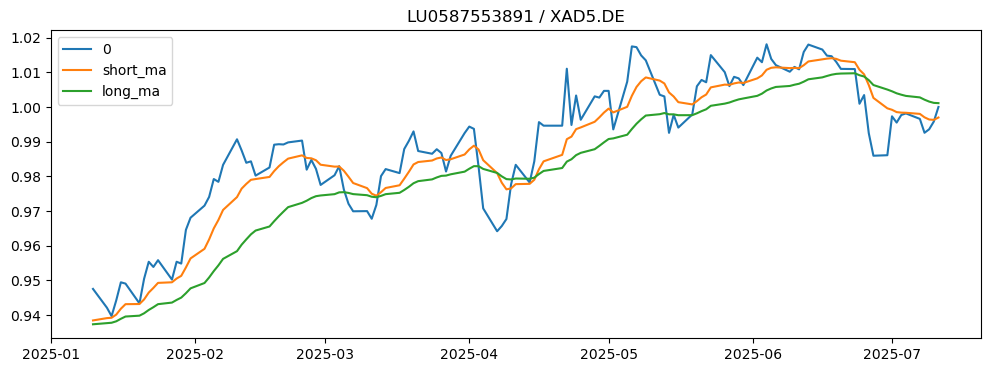

In [20]:
i=27 #17
df_tmp = df_quotes.loc[:get_quote_date(days_ago=365//2)].sort_index()[[df_corr.iloc[i]['ts1'],df_corr.iloc[i]['ts2']]]

mu = mean_historical_return(df_tmp)
S = CovarianceShrinkage(df_tmp).ledoit_wolf()
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
print(weights)
ds_tmp  = weights[df_corr.iloc[i]['ts1']]*df_quotes[df_corr.iloc[i]['ts1']]/df_quotes[df_corr.iloc[i]['ts1']].iloc[0] + weights[df_corr.iloc[i]['ts2']]*df_quotes[df_corr.iloc[i]['ts2']]/df_quotes[df_corr.iloc[i]['ts2']].iloc[0]

_, sma, lma,_,_ = change_trend(ds_tmp)
df_tmp = pd.concat([ds_tmp,sma,lma],axis=1)
title = code2name_dict.get(df_corr.iloc[i]['ts1'],df_corr.iloc[i]['ts1']) + " / " + code2name_dict.get(df_corr.iloc[i]['ts2'],df_corr.iloc[i]['ts2'])
df_tmp.iloc[:130].plot(title=title,figsize=(12,4))
plt.show()

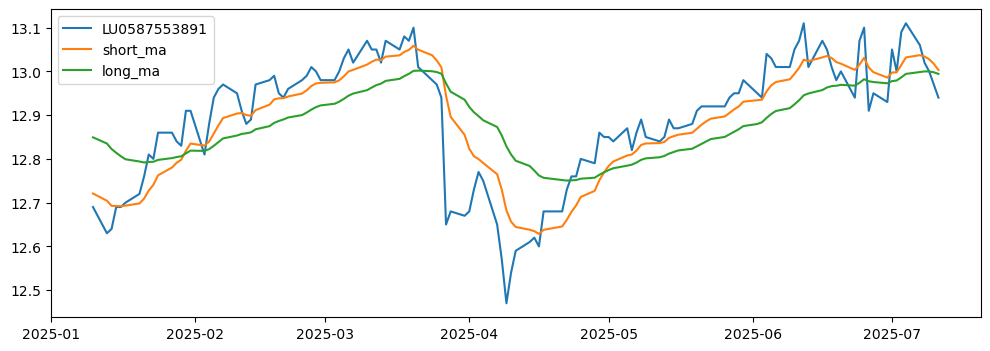

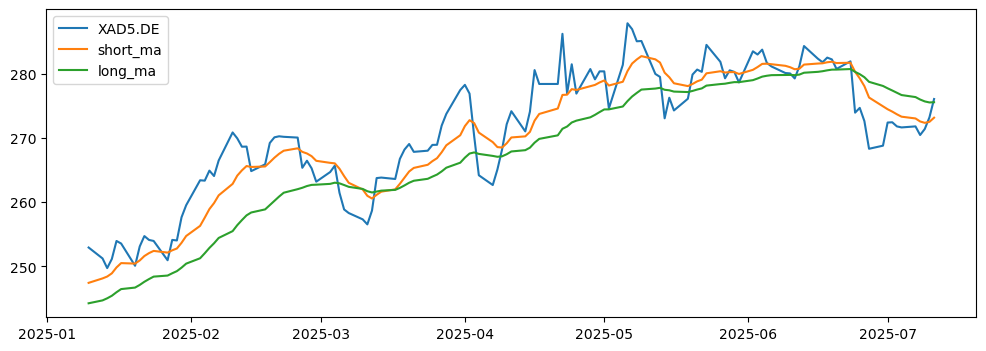

In [21]:
print_fund_change(df_corr.iloc[i]['ts1'])
print_fund_change(df_corr.iloc[i]['ts2'])

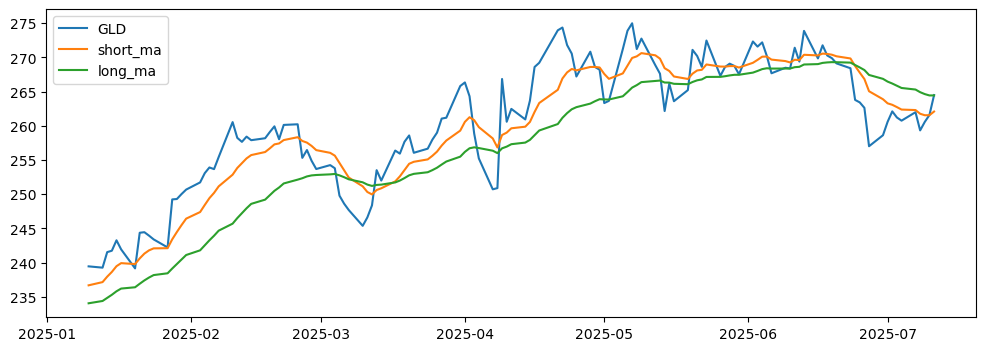

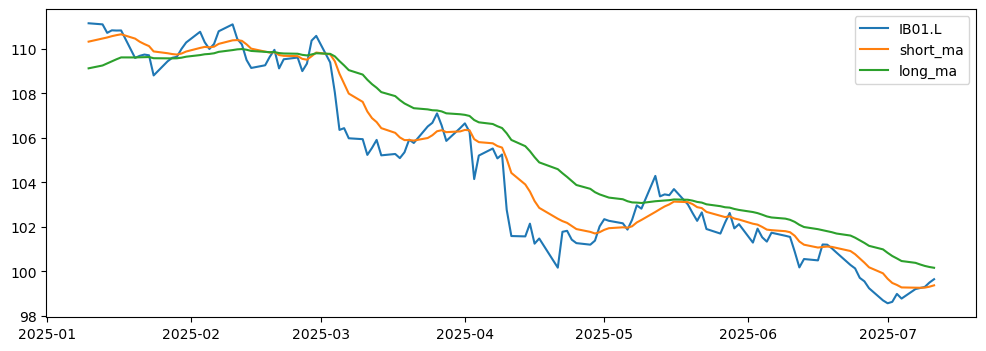

In [22]:
print_fund_change('GLD')
print_fund_change('IB01.L')